# mMTC Slice — 5G Traffic Forecasting
## Hybrid VAR+GRU Deep Learning Comparative Study
**Models:** VAR+GRU+N-BEATS | VAR+GRU+PatchTST | VAR+GRU+TimeMixer | VAR+GRU+TFT  
**Slice:** Massive Machine Type Communications (mMTC)  
**Course:** 22AIE463 — Time Series Analysis | Group B5

In [ ]:
# ==============================================================================
# SETUP & CONFIGURATION
# ==============================================================================
import os, glob, json, warnings, pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
np.random.seed(42); tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# === GPU STRATEGY ===
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("Single Device Mode")

# === SLICE CONFIGURATION ===
SLICE_KEY   = "mmtc"
SLICE_NAME  = "MMTC"
SLICE_LABEL = "mMTC"

CONFIG = {
    "window": 60, "forecast_horizon": 1, "epochs": 150,
    "batch_size": 256, "lr": 0.0001, "var_lags": 3,
    "target_slice": SLICE_NAME,
    "patch_size": 12, "patch_stride": 6
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}
FEATURE_MAP = {
    "throughput": "Throughput_bps", "packets": "Total_Packets",
    "jitter": "Jitter", "latency": "Avg_IAT",
    "reliability": "Retransmission_Ratio", "congestion": "Avg_Win_Size",
    "complexity": "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# === OUTPUT DIRECTORIES ===
OUT = f"/kaggle/working/{SLICE_KEY}"
os.makedirs(f"{OUT}/models", exist_ok=True)
os.makedirs(f"{OUT}/plots", exist_ok=True)
os.makedirs(f"{OUT}/metrics", exist_ok=True)
print(f"Output directory: {OUT}")
print(f"Slice: {SLICE_LABEL} ({SLICE_KEY})")

In [ ]:
# ==============================================================================
# DATA LOADING & PREPROCESSING
# ==============================================================================
def load_and_prep_data(data_path, slice_name):
    print(f"Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files:
        files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files:
        raise FileNotFoundError("No dataset files found!")

    dfs = []
    for f in files:
        try:
            df = pd.read_parquet(f) if f.endswith('.parquet') else pd.read_csv(f)
            dfs.append(df)
        except: pass

    raw_data = pd.concat(dfs, ignore_index=True)
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"Filtering for: '{target_label}'")

    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    if len(df_slice) == 0:
        raise ValueError(f"No data for '{target_label}'.")
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')

    print(f"Loaded {len(df_slice)} samples for {target_label}")
    print(f"Available columns: {list(df_slice.columns)}")

    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        final_df[target] = df_slice[source].copy() if source in df_slice.columns else 0.0
    return final_df.ffill().bfill().fillna(0)

# --- Execute ---
paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
data_path = next((p for p in paths if os.path.exists(p)), ".")
df = load_and_prep_data(data_path, CONFIG['target_slice'])

# --- Splits ---
n = len(df)
train_df = df.iloc[:int(0.7*n)]
val_df   = df.iloc[int(0.7*n):int(0.85*n)]
test_df  = df.iloc[int(0.85*n):]
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# --- Scaling ---
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

# Save scaler
with open(f"{OUT}/metrics/{SLICE_KEY}_scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

# Quick summary
print("\n--- Data Summary ---")
print(df.describe().round(4))

## 1. Pre-Modeling: Exploratory Data Plots & Statistical Tests

In [ ]:
# ==============================================================================
# 1. PRE-MODELING EDA
# ==============================================================================
raw_values = df.values

# --- [1A] Time Series Line Plot (All Features) ---
fig, axes = plt.subplots(len(TARGET_FEATURES), 1, figsize=(16, 3*len(TARGET_FEATURES)), sharex=True)
for i, feat in enumerate(TARGET_FEATURES):
    axes[i].plot(df[feat].values, linewidth=0.7, color=sns.color_palette()[i % 10])
    axes[i].set_ylabel(feat, fontsize=10)
    axes[i].set_title(f'{feat.capitalize()} — {SLICE_LABEL} Raw Time Series', fontsize=11, fontweight='bold')
plt.xlabel('Time Steps')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/01_timeseries_raw.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [1B] STL Decomposition ---
for idx, feat in enumerate(TARGET_FEATURES[:3]):
    series = df[feat].values
    if np.std(series) < 1e-10:
        print(f"Skipping STL for {feat} (flat)")
        continue
    try:
        decomp = seasonal_decompose(series[-min(2000, len(series)):], model='additive', period=CONFIG['window'])
        fig, (a1,a2,a3,a4) = plt.subplots(4,1, figsize=(14,8), sharex=True)
        a1.plot(decomp.observed, color='black'); a1.set_title(f'Observed — {feat}', fontweight='bold')
        a2.plot(decomp.trend, color='orange'); a2.set_title('Trend')
        a3.plot(decomp.seasonal, color='green'); a3.set_title('Seasonal')
        a4.plot(decomp.resid, color='red'); a4.set_title('Residual')
        plt.tight_layout()
        plt.savefig(f"{OUT}/plots/02_stl_{feat}.png", dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"STL failed for {feat}: {e}")

# --- [1C] ADF & KPSS Stationarity Tests ---
stationarity_results = {}
print(f"\n{'='*75}")
print(f"{'FEATURE':<15} | {'ADF Stat':<12} | {'ADF p-val':<12} | {'KPSS Stat':<12} | {'KPSS p-val':<12} | {'Verdict'}")
print(f"{'='*75}")
for feat in TARGET_FEATURES:
    series = df[feat].values
    if np.std(series) < 1e-10:
        stationarity_results[feat] = {"adf_stat": None, "adf_pval": None, "kpss_stat": None, "kpss_pval": None, "verdict": "Flat"}
        print(f"{feat:<15} | {'N/A':<12} | {'N/A':<12} | {'N/A':<12} | {'N/A':<12} | Flat (zero variance)")
        continue
    adf = adfuller(series)
    kp = kpss(series, regression='c', nlags='auto')
    adf_ok = adf[1] < 0.05
    kpss_ok = kp[1] > 0.05
    verdict = "Stationary" if (adf_ok and kpss_ok) else ("Non-Stationary" if (not adf_ok and not kpss_ok) else "Mixed")
    stationarity_results[feat] = {"adf_stat": float(adf[0]), "adf_pval": float(adf[1]), "kpss_stat": float(kp[0]), "kpss_pval": float(kp[1]), "verdict": verdict}
    print(f"{feat:<15} | {adf[0]:<12.4f} | {adf[1]:<12.6f} | {kp[0]:<12.4f} | {kp[1]:<12.6f} | {verdict}")

with open(f"{OUT}/metrics/{SLICE_KEY}_stationarity.json", 'w') as f:
    json.dump(stationarity_results, f, indent=2)

# --- [1D] Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title(f'Feature Correlation Heatmap — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/03_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [1E] Distribution Histograms ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(TARGET_FEATURES):
    axes[i].hist(df[feat].values, bins=50, color=sns.color_palette()[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].axvline(df[feat].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[feat].median(), color='blue', linestyle='--', label='Median')
    axes[i].legend(fontsize=8)
if len(TARGET_FEATURES) < len(axes):
    for j in range(len(TARGET_FEATURES), len(axes)):
        axes[j].set_visible(False)
plt.suptitle(f'Feature Distributions — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/04_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [1F] Rolling Mean & Std ---
window_roll = 100
fig, axes = plt.subplots(len(TARGET_FEATURES), 1, figsize=(16, 3*len(TARGET_FEATURES)), sharex=True)
for i, feat in enumerate(TARGET_FEATURES):
    s = df[feat]
    axes[i].plot(s.values, alpha=0.3, color='gray', linewidth=0.5, label='Raw')
    axes[i].plot(s.rolling(window_roll).mean().values, color='blue', linewidth=1.5, label=f'Rolling Mean ({window_roll})')
    axes[i].plot(s.rolling(window_roll).std().values, color='red', linewidth=1.5, label=f'Rolling Std ({window_roll})')
    axes[i].set_ylabel(feat)
    axes[i].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Rolling Statistics — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/05_rolling_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [1G] Box Plots ---
fig, axes = plt.subplots(1, len(TARGET_FEATURES), figsize=(20, 5))
for i, feat in enumerate(TARGET_FEATURES):
    axes[i].boxplot(df[feat].dropna().values, patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette()[i], alpha=0.6))
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
plt.suptitle(f'Box Plots — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/06_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [1H] Lag Plot ---
for feat in TARGET_FEATURES[:2]:
    s = df[feat].values
    if np.std(s) < 1e-10: continue
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for j, lag in enumerate([1, 7, 30]):
        if lag < len(s):
            axes[j].scatter(s[:-lag], s[lag:], alpha=0.2, s=2, color=sns.color_palette()[j])
            axes[j].set_title(f'Lag={lag}', fontweight='bold')
            axes[j].set_xlabel(f'{feat}(t)'); axes[j].set_ylabel(f'{feat}(t+{lag})')
    plt.suptitle(f'Lag Scatter Plot — {feat} ({SLICE_LABEL})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/07_lag_plot_{feat}.png", dpi=150, bbox_inches='tight')
    plt.show()

# --- [1I] Q-Q Plot ---
for feat in TARGET_FEATURES[:2]:
    s = df[feat].values
    if np.std(s) < 1e-10: continue
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(s, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot — {feat} ({SLICE_LABEL})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/08_qq_plot_{feat}.png", dpi=150, bbox_inches='tight')
    plt.show()

# --- [1J] Violin Plots ---
fig, ax = plt.subplots(figsize=(14, 6))
df_melted = df.melt(var_name='Feature', value_name='Value')
sns.violinplot(x='Feature', y='Value', data=df_melted, ax=ax, inner='quartile', scale='width')
ax.set_title(f'Violin Plots — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUT}/plots/09_violin_plots.png", dpi=150, bbox_inches='tight')
plt.show()

print("Pre-Modeling EDA Complete")

## 2. Baseline Model Identification (VAR Stage)

In [ ]:
# ==============================================================================
# 2. VAR BASELINE — ACF/PACF, AIC/BIC, Residual Extraction
# ==============================================================================

# --- [2A] ACF & PACF Plots (all features) ---
for feat_idx, feat in enumerate(TARGET_FEATURES):
    if np.std(df[feat].values) < 1e-10:
        print(f"Skipping ACF/PACF for {feat} (flat)")
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(df[feat].values[-min(1500, len(df)):], lags=40, ax=axes[0], color='darkblue')
    axes[0].set_title(f'ACF — {feat}', fontweight='bold')
    plot_pacf(df[feat].values[-min(1500, len(df)):], lags=40, ax=axes[1], color='darkred', method='ywm')
    axes[1].set_title(f'PACF — {feat}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/10_acf_pacf_{feat}.png", dpi=150, bbox_inches='tight')
    plt.show()

# --- [2B] VAR Lag Selection ---
print("\nVAR Lag Selection:")
var_results = {}
try:
    var_temp = VAR(train_scaled)
    lag_order = var_temp.select_order(maxlags=15)
    print(lag_order.summary())
except Exception as e:
    print(f"Lag selection table failed: {e}")

# --- [2C] Fit VAR ---
print(f"\nFitting VAR(p={CONFIG['var_lags']})...")
var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
lag = var_model.k_ar

try:
    aic_val = float(var_model.aic)
    bic_val = float(var_model.bic)
    print(f"  AIC: {aic_val:.4f}")
    print(f"  BIC: {bic_val:.4f}")
    var_results['aic'] = aic_val
    var_results['bic'] = bic_val
except:
    print("  AIC/BIC: N/A (singular covariance)")
    var_results['aic'] = None
    var_results['bic'] = None
var_results['lags'] = int(lag)

# --- [2D] VAR Coefficient Heatmap ---
try:
    coef_matrix = var_model.coefs[0]
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(coef_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                xticklabels=TARGET_FEATURES, yticklabels=TARGET_FEATURES, ax=ax)
    ax.set_title(f'VAR(1) Coefficient Matrix — {SLICE_LABEL}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/11_var_coefficients.png", dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"VAR coefficient plot skipped: {e}")

# --- [2E] Granger Causality ---
try:
    print("\nGranger Causality (p-values at lag 3):")
    gc_matrix = np.zeros((len(TARGET_FEATURES), len(TARGET_FEATURES)))
    for i, f1 in enumerate(TARGET_FEATURES):
        for j, f2 in enumerate(TARGET_FEATURES):
            if i != j and np.std(df[f1].values) > 1e-10 and np.std(df[f2].values) > 1e-10:
                try:
                    test_data = df[[f2, f1]].values[-2000:]
                    gc = grangercausalitytests(test_data, maxlag=3, verbose=False)
                    gc_matrix[i, j] = gc[3][0]['ssr_ftest'][1]
                except:
                    gc_matrix[i, j] = 1.0
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(gc_matrix, annot=True, fmt='.3f', cmap='YlOrRd_r',
                xticklabels=TARGET_FEATURES, yticklabels=TARGET_FEATURES, ax=ax)
    ax.set_title(f'Granger Causality p-values — {SLICE_LABEL}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/12_granger_causality.png", dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Granger causality failed: {e}")

# --- [2F] Extract VAR Residuals ---
def get_residuals(data, prev_data):
    if len(prev_data) < lag:
        return data, np.zeros_like(data)
    hist = np.vstack([prev_data[-lag:], data])
    pred = [var_model.forecast(hist[i-lag:i], 1)[0] for i in range(lag, len(hist))]
    return data - np.array(pred), np.array(pred)

res_train, _           = get_residuals(train_scaled[lag:], train_scaled[:lag])
res_val, _             = get_residuals(val_scaled, train_scaled)
res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
print(f"\nResiduals — Train: {res_train.shape}, Val: {res_val.shape}, Test: {res_test.shape}")

# --- Sequence Generation ---
def make_seq(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = make_seq(res_train, CONFIG['window'])
X_val, y_val     = make_seq(res_val, CONFIG['window'])
X_test, y_test   = make_seq(res_test, CONFIG['window'])
print(f"Sequences — X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

with open(f"{OUT}/metrics/{SLICE_KEY}_var_info.json", 'w') as f:
    json.dump(var_results, f, indent=2)

## 3. Model Architectures

In [ ]:
# ==============================================================================
# 3. MODEL ARCHITECTURE DEFINITIONS
# ==============================================================================
NUM_FEATURES = len(TARGET_FEATURES)

# ---- N-BEATS ----
class NBeatsBlock(layers.Layer):
    def __init__(self, units, backcast_length, forecast_length, **kwargs):
        super().__init__(**kwargs)
        self.units=units; self.backcast_length=backcast_length; self.forecast_length=forecast_length
        self.fc1=layers.Dense(units,activation='relu'); self.fc2=layers.Dense(units,activation='relu')
        self.fc3=layers.Dense(units,activation='relu'); self.fc4=layers.Dense(units,activation='relu')
        self.backcast_dense=layers.Dense(backcast_length); self.forecast_dense=layers.Dense(forecast_length)
    def call(self,x):
        h=self.fc4(self.fc3(self.fc2(self.fc1(x))))
        return self.backcast_dense(h), self.forecast_dense(h)

def build_nbeats(input_shape):
    inp=layers.Input(shape=input_shape)
    enc=layers.GRU(128,return_sequences=False,dropout=0.2)(inp)
    b1,f1=NBeatsBlock(64,128,input_shape[-1])(enc); r1=layers.Subtract()([enc,b1])
    b2,f2=NBeatsBlock(64,128,input_shape[-1])(r1);  r2=layers.Subtract()([r1,b2])
    b3,f3=NBeatsBlock(64,128,input_shape[-1])(r2)
    out=layers.Add()([f1,f2,f3])
    m=models.Model(inp,out,name="VAR_GRU_NBEATS")
    m.compile(optimizer=optimizers.Adam(CONFIG['lr']),loss=losses.Huber(delta=1.0),metrics=['mae'])
    return m

# ---- PatchTST ----
class PatchTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha=layers.MultiHeadAttention(num_heads=num_heads,key_dim=d_model)
        self.ffn=models.Sequential([layers.Dense(ff_dim,activation='gelu'),layers.Dense(d_model)])
        self.ln1=layers.LayerNormalization(epsilon=1e-6); self.ln2=layers.LayerNormalization(epsilon=1e-6)
        self.d1=layers.Dropout(dropout); self.d2=layers.Dropout(dropout)
    def call(self,inputs,training=False):
        a=self.d1(self.mha(inputs,inputs),training=training); o1=self.ln1(inputs+a)
        return self.ln2(o1+self.d2(self.ffn(o1),training=training))

def build_patchtst(input_shape):
    inp=layers.Input(shape=input_shape)
    x=layers.GRU(64,return_sequences=True,dropout=0.1)(inp)
    d_model=64
    x=layers.Conv1D(d_model,kernel_size=CONFIG['patch_size'],strides=CONFIG['patch_stride'],padding='valid')(x)
    num_patches=(CONFIG['window']-CONFIG['patch_size'])//CONFIG['patch_stride']+1
    pos=tf.range(start=0,limit=num_patches,delta=1)
    x=x+layers.Embedding(input_dim=num_patches,output_dim=d_model)(pos)
    x=PatchTransformerBlock(d_model,4,128)(x)
    x=PatchTransformerBlock(d_model,4,128)(x)
    x=layers.GlobalAveragePooling1D()(x)
    x=layers.Dense(64,activation='gelu')(x); x=layers.Dropout(0.1)(x)
    out=layers.Dense(input_shape[-1])(x)
    m=models.Model(inp,out,name="VAR_GRU_PatchTST")
    m.compile(optimizer=optimizers.Adam(CONFIG['lr']),loss=losses.Huber(delta=1.0),metrics=['mae'])
    return m

# ---- TimeMixer ----
class MixingBlock(layers.Layer):
    def __init__(self, seq_len, num_features, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.seq_len=seq_len; self.num_features=num_features
        self.norm1=layers.LayerNormalization(epsilon=1e-6); self.norm2=layers.LayerNormalization(epsilon=1e-6)
        self.time_dense=layers.Dense(seq_len,activation='gelu'); self.time_drop=layers.Dropout(dropout)
        self.feat1=layers.Dense(num_features*2,activation='gelu'); self.feat2=layers.Dense(num_features)
        self.feat_drop=layers.Dropout(dropout)
    def call(self,inputs,training=False):
        x=self.norm1(inputs); x=tf.transpose(x,perm=[0,2,1]); x=self.time_dense(x)
        x=self.time_drop(x,training=training); x=tf.transpose(x,perm=[0,2,1]); res=x+inputs
        x=self.norm2(res); x=self.feat1(x); x=self.feat_drop(x,training=training); x=self.feat2(x)
        return x+res

class MultiScaleTimeMixer(layers.Layer):
    def __init__(self, original_len, num_features, **kwargs):
        super().__init__(**kwargs)
        self.ol=original_len; self.nf=num_features
        self.m1=MixingBlock(original_len,num_features)
        self.p2=layers.AveragePooling1D(2,2,'valid'); self.m2=MixingBlock(original_len//2,num_features)
        self.p4=layers.AveragePooling1D(4,4,'valid'); self.m3=MixingBlock(original_len//4,num_features)
    def call(self,x):
        o1=self.m1(x)
        o2=self.m2(self.p2(x))
        o2=tf.squeeze(tf.image.resize(tf.expand_dims(o2,-1),[self.ol,self.nf],method='nearest'),-1)
        o3=self.m3(self.p4(x))
        o3=tf.squeeze(tf.image.resize(tf.expand_dims(o3,-1),[self.ol,self.nf],method='nearest'),-1)
        return o1+o2+o3

def build_timemixer(input_shape):
    inp=layers.Input(shape=input_shape)
    x=layers.GRU(64,return_sequences=True,dropout=0.2)(inp)
    x=layers.Dense(input_shape[-1])(x)
    x=MultiScaleTimeMixer(input_shape[0],input_shape[-1])(x)
    x=MultiScaleTimeMixer(input_shape[0],input_shape[-1])(x)
    x=layers.Flatten()(x); x=layers.Dense(64,activation='gelu')(x); x=layers.Dropout(0.1)(x)
    out=layers.Dense(input_shape[-1])(x)
    m=models.Model(inp,out,name="VAR_GRU_TimeMixer")
    m.compile(optimizer=optimizers.Adam(CONFIG['lr']),loss=losses.Huber(delta=1.0),metrics=['mae'])
    return m

# ---- TFT ----
class GatedResidualNetwork(layers.Layer):
    def __init__(self, units, dropout, **kwargs):
        super().__init__(**kwargs)
        self.units=units
        self.elu_dense=layers.Dense(units,activation='elu'); self.linear_dense=layers.Dense(units)
        self.drop=layers.Dropout(dropout); self.gate=layers.Dense(units,activation='sigmoid')
        self.norm=layers.LayerNormalization(); self.skip_project=None
    def build(self,input_shape):
        if input_shape[-1]!=self.units: self.skip_project=layers.Dense(self.units)
        super().build(input_shape)
    def call(self,x):
        skip=self.skip_project(x) if self.skip_project else x
        v=self.elu_dense(x); v=self.drop(v); v=self.linear_dense(v); v=v*self.gate(x)
        return self.norm(skip+v)

def build_tft(input_shape):
    inp=layers.Input(shape=input_shape)
    x=GatedResidualNetwork(64,0.1)(inp)
    x=layers.GRU(128,return_sequences=True,dropout=0.2)(x)
    x=layers.GRU(64,return_sequences=True,dropout=0.2)(x)
    x=layers.MultiHeadAttention(num_heads=4,key_dim=32)(x,x)
    x=layers.LayerNormalization()(x)
    x=layers.GlobalAveragePooling1D()(x)
    x=GatedResidualNetwork(32,0.1)(x)
    out=layers.Dense(input_shape[-1])(x)
    m=models.Model(inp,out,name="VAR_GRU_TFT")
    m.compile(optimizer=optimizers.Adam(CONFIG['lr']),loss=losses.Huber(delta=1.0),metrics=['mae'])
    return m

# Registry
MODEL_BUILDERS = {
    "nbeats":    build_nbeats,
    "patchtst":  build_patchtst,
    "timemixer": build_timemixer,
    "tft":       build_tft
}

MODEL_DISPLAY = {
    "nbeats": "VAR+GRU+N-BEATS", "patchtst": "VAR+GRU+PatchTST",
    "timemixer": "VAR+GRU+TimeMixer", "tft": "VAR+GRU+TFT"
}

print("All 4 model architectures defined.")
for k, builder in MODEL_BUILDERS.items():
    m = builder((CONFIG['window'], NUM_FEATURES))
    print(f"  {MODEL_DISPLAY[k]}: {m.count_params():,} parameters")
    del m

## 4. Training Pipeline

In [ ]:
# ==============================================================================
# 4. TRAIN ALL 4 MODELS
# ==============================================================================
trained_models = {}
training_histories = {}

for model_key, builder in MODEL_BUILDERS.items():
    print(f"\n{'='*60}")
    print(f"  TRAINING: {MODEL_DISPLAY[model_key]}")
    print(f"{'='*60}")

    with strategy.scope():
        model = builder((CONFIG['window'], NUM_FEATURES))

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6),
            callbacks.CSVLogger(f"{OUT}/metrics/{SLICE_KEY}_{model_key}_history.csv")
        ],
        verbose=1
    )

    trained_models[model_key] = model
    training_histories[model_key] = history.history

    # Save model
    model.save(f"{OUT}/models/{SLICE_KEY}_{model_key}.h5")
    print(f"  Saved: {OUT}/models/{SLICE_KEY}_{model_key}.h5")

    # --- Training vs Validation Loss Plot ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['loss'], label='Train Loss (Huber)', color='blue')
    ax1.plot(history.history['val_loss'], label='Val Loss (Huber)', color='red')
    ax1.set_title(f'Loss — {MODEL_DISPLAY[model_key]}', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Huber Loss'); ax1.legend()

    ax2.plot(history.history['mae'], label='Train MAE', color='blue')
    ax2.plot(history.history['val_mae'], label='Val MAE', color='red')
    ax2.set_title(f'MAE — {MODEL_DISPLAY[model_key]}', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE'); ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/13_training_loss_{model_key}.png", dpi=150, bbox_inches='tight')
    plt.show()

print("\nAll 4 models trained and saved!")

## 5. Comprehensive Evaluation & Diagnostics

In [ ]:
# ==============================================================================
# 5. COMPREHENSIVE EVALUATION
# ==============================================================================
all_metrics = {}
all_predictions = {}

y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+len(X_test)])

for model_key, model in trained_models.items():
    print(f"\n{'='*60}")
    print(f"  EVALUATING: {MODEL_DISPLAY[model_key]}")
    print(f"{'='*60}")

    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    y_pred_real = np.maximum(scaler.inverse_transform(final_pred), 0)
    all_predictions[model_key] = y_pred_real

    # --- Per-Feature Metrics ---
    model_metrics = {"features": {}, "overall": {}}
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12} | {'R²':<12}")
    print("-" * 55)
    rmses, maes, r2s = [], [], []
    for i, feat in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:L, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:L, i], y_pred_real[:, i])
        r2 = r2_score(y_true_real[:L, i], y_pred_real[:, i])
        rmses.append(rmse); maes.append(mae); r2s.append(r2)
        model_metrics["features"][feat] = {"rmse": float(rmse), "mae": float(mae), "r2": float(r2)}
        print(f"{feat:<15} | {rmse:<12.4f} | {mae:<12.4f} | {r2:<12.4f}")

    model_metrics["overall"] = {
        "avg_rmse": float(np.mean(rmses)), "avg_mae": float(np.mean(maes)), "avg_r2": float(np.mean(r2s))
    }
    all_metrics[model_key] = model_metrics

    # --- [5A] Forecast vs Actual (All Features Grid) ---
    fig, axes = plt.subplots(len(TARGET_FEATURES), 1, figsize=(16, 3*len(TARGET_FEATURES)), sharex=True)
    ZOOM = min(300, L)
    for i, feat in enumerate(TARGET_FEATURES):
        axes[i].plot(y_true_real[-ZOOM:, i], color='black', alpha=0.8, linewidth=1, label='Actual')
        axes[i].plot(y_pred_real[-ZOOM:, i], color='red', linestyle='--', linewidth=1.5, label='Predicted')
        axes[i].set_ylabel(feat); axes[i].legend(fontsize=8, loc='upper right')
    plt.suptitle(f'Forecast vs Actual (All Features) — {MODEL_DISPLAY[model_key]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/14_forecast_all_{model_key}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- [5B] Zoomed Forecast (Throughput) ---
    plt.figure(figsize=(14, 5))
    plt.plot(y_true_real[-ZOOM:, 0], color='black', alpha=0.8, linewidth=1.5, label='Actual (Throughput)')
    plt.plot(y_pred_real[-ZOOM:, 0], color='red', linestyle='--', linewidth=2, label=f'{MODEL_DISPLAY[model_key]} Forecast')
    r2_thr = r2_score(y_true_real[:L, 0], y_pred_real[:, 0])
    plt.title(f'Throughput Forecast — {MODEL_DISPLAY[model_key]} (R²={r2_thr:.4f})', fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps'); plt.ylabel('Throughput (bps)'); plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUT}/plots/15_forecast_throughput_{model_key}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # --- [5C] Residual Diagnostics ---
    for feat_idx in [0, 3]:
        feat = TARGET_FEATURES[feat_idx]
        residuals = y_true_real[:L, feat_idx] - y_pred_real[:, feat_idx]
        if np.std(residuals) < 1e-10:
            print(f"  Skipping residual tests for {feat} (zero variance)")
            continue

        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        plot_acf(residuals, lags=40, ax=axes[0,0], color='purple')
        axes[0,0].set_title(f'Residual ACF — {feat}', fontweight='bold')
        axes[0,1].plot(residuals**2, color='gray', alpha=0.7)
        axes[0,1].set_title(f'Squared Residuals — {feat}', fontweight='bold')
        axes[1,0].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black', density=True)
        x_range = np.linspace(residuals.min(), residuals.max(), 100)
        axes[1,0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), 'r-', linewidth=2)
        axes[1,0].set_title(f'Residual Distribution — {feat}', fontweight='bold')
        stats.probplot(residuals, dist="norm", plot=axes[1,1])
        axes[1,1].set_title(f'Q-Q Plot (Residuals) — {feat}', fontweight='bold')
        plt.suptitle(f'{MODEL_DISPLAY[model_key]} — Residual Diagnostics ({feat})', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{OUT}/plots/16_residuals_{model_key}_{feat}.png", dpi=150, bbox_inches='tight')
        plt.show()

        try:
            lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
            lb_p = lb['lb_pvalue'].values[0]
            arch = het_arch(residuals)
            model_metrics["features"][feat]["ljung_box_pval"] = float(lb_p)
            model_metrics["features"][feat]["arch_lm_pval"] = float(arch[1])
            print(f"  {feat} — Ljung-Box p={lb_p:.6f} ({'White Noise' if lb_p>0.05 else 'Structure'}) | ARCH LM p={arch[1]:.6f} ({'No Clustering' if arch[1]>0.05 else 'Clustering'})")
        except Exception as e:
            print(f"  Residual tests failed for {feat}: {e}")

# --- [5D] Model Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names_disp = [MODEL_DISPLAY[k] for k in all_metrics.keys()]
avg_rmses = [all_metrics[k]["overall"]["avg_rmse"] for k in all_metrics.keys()]
avg_r2s = [all_metrics[k]["overall"]["avg_r2"] for k in all_metrics.keys()]
colors_bar = ['#8B0000', '#2E7D32', '#E65100', '#9C27B0']

axes[0].barh(model_names_disp, avg_rmses, color=colors_bar[:len(model_names_disp)])
axes[0].set_title('Average RMSE (lower is better)', fontweight='bold')
axes[0].set_xlabel('RMSE')
axes[1].barh(model_names_disp, avg_r2s, color=colors_bar[:len(model_names_disp)])
axes[1].set_title('Average R² (higher is better)', fontweight='bold')
axes[1].set_xlabel('R²')
plt.suptitle(f'Model Comparison — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/17_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [5E] Radar Chart ---
best_key = max(all_metrics.keys(), key=lambda k: all_metrics[k]["overall"]["avg_r2"])
best_r2_per_feat = [max(0, all_metrics[best_key]["features"][f]["r2"]) * 100 for f in TARGET_FEATURES]
angles = np.linspace(0, 2*np.pi, len(TARGET_FEATURES), endpoint=False).tolist()
angles += angles[:1]; best_r2_per_feat += best_r2_per_feat[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, best_r2_per_feat, color='crimson', alpha=0.25)
ax.plot(angles, best_r2_per_feat, 'o-', color='crimson', linewidth=2)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(TARGET_FEATURES)
ax.set_ylim(0, 100); ax.set_title(f'Per-KPI R² (%) — {MODEL_DISPLAY[best_key]} ({SLICE_LABEL})', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{OUT}/plots/18_radar_r2.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [5F] All Models Overlay ---
plt.figure(figsize=(16, 6)); ZOOM = min(200, L)
plt.plot(y_true_real[-ZOOM:, 0], color='black', linewidth=2, label='Actual', alpha=0.9)
line_styles = ['-', '--', '-.', ':']
for idx, (mk, yp) in enumerate(all_predictions.items()):
    plt.plot(yp[-ZOOM:, 0], color=colors_bar[idx], linestyle=line_styles[idx], linewidth=1.5, label=MODEL_DISPLAY[mk], alpha=0.8)
plt.title(f'All Models vs Actual — Throughput ({SLICE_LABEL})', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps'); plt.ylabel('Throughput (bps)'); plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/plots/19_all_models_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [5G] Feature-wise RMSE ---
fig, ax = plt.subplots(figsize=(14, 6)); x = np.arange(len(TARGET_FEATURES)); width = 0.2
for idx, (mk, met) in enumerate(all_metrics.items()):
    rmse_vals = [met["features"][f]["rmse"] for f in TARGET_FEATURES]
    ax.bar(x + idx*width, rmse_vals, width, label=MODEL_DISPLAY[mk], color=colors_bar[idx])
ax.set_xticks(x + width*1.5); ax.set_xticklabels(TARGET_FEATURES, rotation=45)
ax.set_title(f'Per-Feature RMSE Comparison — {SLICE_LABEL}', fontweight='bold')
ax.set_ylabel('RMSE'); ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/plots/20_feature_rmse_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [5H] Error Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10)); axes = axes.flatten()
for idx, (mk, yp) in enumerate(all_predictions.items()):
    errors = y_true_real[:L, 0] - yp[:, 0]
    axes[idx].hist(errors, bins=50, color=colors_bar[idx], alpha=0.7, edgecolor='black', density=True)
    axes[idx].axvline(0, color='black', linestyle='--')
    axes[idx].set_title(f'{MODEL_DISPLAY[mk]} — Error Distribution', fontweight='bold')
plt.suptitle(f'Prediction Error Distributions — {SLICE_LABEL}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/21_error_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [5I] CUSUM ---
plt.figure(figsize=(14, 4))
best_errors = y_true_real[:L, 0] - all_predictions[best_key][:, 0]
cusum = np.cumsum(best_errors - best_errors.mean())
plt.plot(cusum, color='darkblue', linewidth=1.5); plt.axhline(0, color='red', linestyle='--')
plt.title(f'CUSUM Chart — {MODEL_DISPLAY[best_key]} ({SLICE_LABEL})', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}/plots/22_cusum.png", dpi=150, bbox_inches='tight')
plt.show()

# --- [5J] Spectral Density ---
from numpy.fft import fft, fftfreq
s = y_true_real[:L, 0]
if np.std(s) > 1e-10:
    N = len(s); yf = 2.0/N * np.abs(fft(s)[:N//2]); xf = fftfreq(N, 1)[:N//2]
    plt.figure(figsize=(14, 4)); plt.plot(xf[1:], yf[1:], color='navy', linewidth=0.8)
    plt.title(f'Power Spectral Density — throughput ({SLICE_LABEL})', fontweight='bold')
    plt.xlabel('Frequency'); plt.ylabel('Amplitude'); plt.tight_layout()
    plt.savefig(f"{OUT}/plots/23_spectral_density.png", dpi=150, bbox_inches='tight'); plt.show()

print("\nEvaluation complete!")

In [ ]:
# ==============================================================================
# 6. SAVE ALL ARTIFACTS
# ==============================================================================
webapp_metrics = {"slice": SLICE_KEY, "slice_label": SLICE_LABEL, "models": {}}

for mk in all_metrics:
    mm = all_metrics[mk]
    webapp_metrics["models"][mk] = {
        "display_name": MODEL_DISPLAY[mk],
        "throughput_rmse": mm["features"]["throughput"]["rmse"],
        "latency_rmse": mm["features"]["latency"]["rmse"],
        "jitter_rmse": mm["features"]["jitter"]["rmse"],
        "packets_rmse": mm["features"]["packets"]["rmse"],
        "reliability_rmse": mm["features"]["reliability"]["rmse"],
        "congestion_rmse": mm["features"]["congestion"]["rmse"],
        "avg_rmse": mm["overall"]["avg_rmse"],
        "avg_mae": mm["overall"]["avg_mae"],
        "avg_r2": mm["overall"]["avg_r2"],
        "per_feature": mm["features"]
    }

best_key = max(all_metrics.keys(), key=lambda k: all_metrics[k]["overall"]["avg_r2"])
webapp_metrics["radar"] = {
    "best_model": MODEL_DISPLAY[best_key],
    "labels": TARGET_FEATURES,
    "values": [max(0, all_metrics[best_key]["features"][f]["r2"]) * 100 for f in TARGET_FEATURES]
}
webapp_metrics["charts"] = {
    "model_names": [MODEL_DISPLAY[mk] for mk in MODEL_BUILDERS.keys()],
    "rmse": [all_metrics[mk]["features"]["throughput"]["rmse"] for mk in MODEL_BUILDERS.keys()],
    "mae": [all_metrics[mk]["features"]["throughput"]["mae"] for mk in MODEL_BUILDERS.keys()]
}

best_pred = all_predictions[best_key]
EXPORT_LEN = min(300, len(best_pred))
webapp_metrics["predictions"] = {
    "model": MODEL_DISPLAY[best_key],
    "labels": list(range(EXPORT_LEN)),
    "actual": y_true_real[-EXPORT_LEN:, 0].tolist(),
    "predicted": best_pred[-EXPORT_LEN:, 0].tolist(),
    "r2_score": float(r2_score(y_true_real[:len(best_pred), 0], best_pred[:, 0]))
}

webapp_metrics["results_table"] = []
for mk in MODEL_BUILDERS.keys():
    mm = all_metrics[mk]
    webapp_metrics["results_table"].append({
        "model": MODEL_DISPLAY[mk],
        "throughputRMSE": round(mm["features"]["throughput"]["rmse"], 4),
        "latencyRMSE": round(mm["features"]["latency"]["rmse"], 6),
        "jitterRMSE": round(mm["features"]["jitter"]["rmse"], 6),
        "packetsRMSE": round(mm["features"]["packets"]["rmse"], 4),
        "r2": round(mm["overall"]["avg_r2"], 4),
        "bestSlice": SLICE_LABEL
    })

with open(f"{OUT}/metrics/{SLICE_KEY}_webapp_metrics.json", 'w') as f:
    json.dump(webapp_metrics, f, indent=2)

for mk, pred in all_predictions.items():
    np.save(f"{OUT}/metrics/{SLICE_KEY}_{mk}_predictions.npy", pred)
np.save(f"{OUT}/metrics/{SLICE_KEY}_true_values.npy", y_true_real)

print(f"\n{'='*60}")
print(f"  ALL ARTIFACTS SAVED TO: {OUT}")
print(f"{'='*60}")
for root, dirs, files_list in os.walk(OUT):
    level = root.replace(OUT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files_list:
        fsize = os.path.getsize(os.path.join(root, file))
        print(f'{subindent}{file} ({fsize/1024:.1f} KB)')

print(f"\nDownload the entire '{SLICE_KEY}/' folder from Kaggle Output")
print("and place contents in your workspace as described in KAGGLE_INSTRUCTIONS.md")

In [2]:
# =====================================================
# STABILIZED VAR + BiLSTM + BAHDANAU ATTENTION MODEL
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC"   # eMBB, URLLC, mMTC
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (BiLSTM + BAHDANAU)
# =====================================================
def build_bilstm_attention_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Sequence Encoding with BiLSTM
    # return_sequences=True is required for attention to look at all time steps
    # return_state=True grabs the final hidden states for our attention query
    lstm_out, forward_h, forward_c, backward_h, backward_c = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, return_state=True, dropout=0.2)
    )(inputs)
    
    # 2. Query Preparation
    # Concatenate the final forward and backward hidden states
    query_state = layers.Concatenate()([forward_h, backward_h])
    # Expand dimensions to match the sequence shape required by AdditiveAttention: (batch_size, 1, hidden_dim)
    query_seq = layers.Reshape((1, query_state.shape[-1]))(query_state)
    
    # 3. Bahdanau (Additive) Attention
    # The mechanism compares the query sequence with the full sequence of BiLSTM outputs (values)
    context_vector, attention_weights = layers.AdditiveAttention(use_scale=True, name="Bahdanau_Attention")(
        [query_seq, lstm_out], return_attention_scores=True
    )
    
    # 4. Decoder / Prediction Head
    x = layers.Flatten()(context_vector)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Output layer predicts all target features simultaneously
    outputs = layers.Dense(input_shape[-1])(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="VAR_BiLSTM_Bahdanau")
    
    # Huber loss handles outliers (like sudden latency bursts) cleanly
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        # Passed 7 as feature dimension based on TARGET_FEATURES length
        model = build_bilstm_attention_model((CONFIG['window'], 7))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12}")
    print("-" * 45)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f}")
        
    model.save("VAR_BiLSTM_Bahdanau_Model.h5")
    print("\n✅ Saved: VAR_BiLSTM_Bahdanau_Model.h5")

if __name__ == "__main__":
    run_pipeline()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
🚀 ACCELERATION: Running on 1 GPU(s)
🔍 Scanning: /kaggle/input


2026-03-05 16:34:27.002887: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - loss: 0.0201 - mae: 0.0420 - val_loss: 0.0269 - val_mae: 0.0485 - learning_rate: 1.0000e-04
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 375ms/step - loss: 0.0200 - mae: 0.0383 - val_loss: 0.0269 - val_mae: 0.0452 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step - loss: 0.0200 - mae: 0.0371 - val_loss: 0.0269 - val_mae: 0.0453 - learning_rate: 1.0000e-04
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - loss: 0.0200 - mae: 0.0370 - val_loss: 0.0268 - val_mae: 0.0452 - learning_rate: 1.0000e-04
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step - loss: 0.0199 - mae: 0.0372 - val_loss: 0.0268 - val_mae: 0.0454 - learning_rate: 1.0000e-04
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step - loss: 0.0199 - mae: 0.0375 - val_loss: 0.0267 - val_mae: 0.0456 


FEATURE         | RMSE         | MAE         
---------------------------------------------
throughput      | 3695.2413    | 406.7699    
packets         | 2.8907       | 0.2790      
jitter          | 0.0034       | 0.0003      
latency         | 0.0014       | 0.0004      
reliability     | 0.0035       | 0.0029      
congestion      | 0.0060       | 0.0049      
complexity      | 0.0054       | 0.0036      

✅ Saved: VAR_BiLSTM_Bahdanau_Model.h5


## VAR+GRU+N-beats

In [3]:
# =====================================================
# STABILIZED VAR + GRU + N-BEATS MODEL
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC"   # eMBB, URLLC, mMTC
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (GRU + N-BEATS)
# =====================================================
class NBeatsBlock(layers.Layer):
    """
    Standard N-BEATS Block: 
    Applies FC layers to compute a 'backcast' (reconstruction of input) 
    and a 'forecast' (contribution to the final prediction).
    """
    def __init__(self, units, backcast_length, forecast_length, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        
        self.fc1 = layers.Dense(units, activation='relu')
        self.fc2 = layers.Dense(units, activation='relu')
        self.fc3 = layers.Dense(units, activation='relu')
        self.fc4 = layers.Dense(units, activation='relu')
        
        self.backcast_dense = layers.Dense(backcast_length)
        self.forecast_dense = layers.Dense(forecast_length)
        
    def call(self, x):
        h = self.fc1(x)
        h = self.fc2(h)
        h = self.fc3(h)
        h = self.fc4(h)
        
        backcast = self.backcast_dense(h)
        forecast = self.forecast_dense(h)
        
        return backcast, forecast

def build_gru_nbeats_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Temporal Encoding (GRU)
    # The GRU learns the temporal relationships of the 5G anomalies and 
    # compresses them into a fixed-length encoding (128 units).
    gru_encoding = layers.GRU(128, return_sequences=False, dropout=0.2)(inputs)
    
    # 2. Doubly Residual N-BEATS Stacks
    # Stack 1
    b1, f1 = NBeatsBlock(units=64, backcast_length=128, forecast_length=input_shape[-1])(gru_encoding)
    res1 = layers.Subtract()([gru_encoding, b1]) # Subtract reconstruction from the original encoding
    
    # Stack 2
    b2, f2 = NBeatsBlock(units=64, backcast_length=128, forecast_length=input_shape[-1])(res1)
    res2 = layers.Subtract()([res1, b2])
    
    # Stack 3
    b3, f3 = NBeatsBlock(units=64, backcast_length=128, forecast_length=input_shape[-1])(res2)
    
    # 3. Final Prediction
    # The final forecast is the sum of the partial forecasts from all stacks
    outputs = layers.Add(name="NBeats_Forecast_Accumulation")([f1, f2, f3])
    
    model = models.Model(inputs=inputs, outputs=outputs, name="VAR_GRU_NBEATS")
    
    # Huber loss handles outliers cleanly
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        # Passed 7 as feature dimension based on TARGET_FEATURES length
        model = build_gru_nbeats_model((CONFIG['window'], len(TARGET_FEATURES)))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12}")
    print("-" * 45)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f}")
        
    model.save("VAR_GRU_NBEATS_Model.h5")
    print("\n✅ Saved: VAR_GRU_NBEATS_Model.h5")

if __name__ == "__main__":
    run_pipeline()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


🚀 ACCELERATION: Running on 1 GPU(s)
🔍 Scanning: /kaggle/input
✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - loss: 0.0199 - mae: 0.0397 - val_loss: 0.0252 - val_mae: 0.0462 - learning_rate: 1.0000e-04
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - loss: 0.0185 - mae: 0.0359 - val_loss: 0.0230 - val_mae: 0.0445 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - loss: 0.0169 - mae: 0.0370 - val_loss: 0.0200 - val_mae: 0.0394 - learning_rate: 1.0000e-04
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - loss: 0.0150 - mae: 0.0347 - val_loss: 0.0176 - val_mae: 0.0370 - learning_rate: 1.0000e-04
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.0136 - mae: 0.0325 - val_loss: 0.0172 - val_mae: 0.0344 - learning_rate: 1.0000e-04
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - loss: 


FEATURE         | RMSE         | MAE         
---------------------------------------------
throughput      | 3707.2844    | 366.8460    
packets         | 2.9195       | 0.2636      
jitter          | 0.0082       | 0.0030      
latency         | 0.0064       | 0.0019      
reliability     | 0.0062       | 0.0007      
congestion      | 0.0024       | 0.0005      
complexity      | 0.0047       | 0.0017      

✅ Saved: VAR_GRU_NBEATS_Model.h5


## VAR+GRU+Patch TST

In [4]:
# =====================================================
# STABILIZED VAR + GRU + PatchTST MODEL
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC",  # eMBB, URLLC, mMTC
    "patch_size": 12,        # Size of each patch (e.g., 12 time steps)
    "patch_stride": 6        # Overlap stride
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (GRU + PatchTST)
# =====================================================
class PatchTransformerBlock(layers.Layer):
    """
    Standard Transformer Encoder block applied to patched sequences.
    Fixes the O(L^2) attention complexity by computing attention over patches.
    """
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation='gelu'),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        attn_output = self.mha(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_gru_patchtst_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Temporal Encoding (GRU)
    # Extracts sequential anomalies before patchification
    x = layers.GRU(64, return_sequences=True, dropout=0.1)(inputs)
    
    # 2. Patchification (via Conv1D)
    # Splits the time series into non-overlapping or overlapping patches
    d_model = 64
    x = layers.Conv1D(
        filters=d_model, 
        kernel_size=CONFIG["patch_size"], 
        strides=CONFIG["patch_stride"], 
        padding='valid', 
        activation='linear'
    )(x)
    
    # Calculate the number of patches resulting from the convolution
    num_patches = (CONFIG["window"] - CONFIG["patch_size"]) // CONFIG["patch_stride"] + 1
    
    # 3. Positional Embedding
    positions = tf.range(start=0, limit=num_patches, delta=1)
    pos_emb = layers.Embedding(input_dim=num_patches, output_dim=d_model)(positions)
    x = x + pos_emb
    
    # 4. PatchTST Transformer Layers
    x = PatchTransformerBlock(d_model=d_model, num_heads=4, ff_dim=128)(x)
    x = PatchTransformerBlock(d_model=d_model, num_heads=4, ff_dim=128)(x)
    
    # 5. Global Pooling and Prediction Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='gelu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Predict all target features simultaneously
    outputs = layers.Dense(input_shape[-1])(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="VAR_GRU_PatchTST")
    
    # Huber loss handles outliers cleanly
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        # Passed dimension based on TARGET_FEATURES length
        model = build_gru_patchtst_model((CONFIG['window'], len(TARGET_FEATURES)))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12}")
    print("-" * 45)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f}")
        
    model.save("VAR_GRU_PatchTST_Model.h5")
    print("\n✅ Saved: VAR_GRU_PatchTST_Model.h5")

if __name__ == "__main__":
    run_pipeline()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


🚀 ACCELERATION: Running on 1 GPU(s)
🔍 Scanning: /kaggle/input
✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 290ms/step - loss: 0.0458 - mae: 0.1963 - val_loss: 0.0281 - val_mae: 0.0817 - learning_rate: 1.0000e-04
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - loss: 0.0238 - mae: 0.1027 - val_loss: 0.0269 - val_mae: 0.0689 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - loss: 0.0222 - mae: 0.0895 - val_loss: 0.0263 - val_mae: 0.0665 - learning_rate: 1.0000e-04
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - loss: 0.0215 - mae: 0.0856 - val_loss: 0.0258 - val_mae: 0.0644 - learning_rate: 1.0000e-04
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - loss: 0.0210 - mae: 0.0832 - val_loss: 0.0252 - val_mae: 0.0662 - learning_rate: 1.0000e-04
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - loss: 

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step



FEATURE         | RMSE         | MAE         
---------------------------------------------
throughput      | 3647.6277    | 478.7488    
packets         | 2.8781       | 0.2823      
jitter          | 0.0067       | 0.0024      
latency         | 0.0076       | 0.0022      
reliability     | 0.0117       | 0.0061      
congestion      | 0.0081       | 0.0032      
complexity      | 0.0118       | 0.0064      

✅ Saved: VAR_GRU_PatchTST_Model.h5


In [5]:
# =====================================================
# STABILIZED VAR + GRU + iTransformer MODEL
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size (Lookback)
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC"   # eMBB, URLLC, mMTC
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (GRU + iTransformer)
# =====================================================
class iTransformerBlock(layers.Layer):
    """
    Inverted Transformer Block:
    Applies Multi-Head Attention ACROSS the feature dimension (variates), 
    not across the time dimension.
    """
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation='gelu'),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        # Attention across features
        attn_output = self.mha(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_gru_itransformer_model(input_shape):
    inputs = layers.Input(shape=input_shape) # Shape: (window, num_features)
    
    # 1. Temporal Encoding (GRU)
    # Extracts sequential anomalies before inversion
    gru_out = layers.GRU(64, return_sequences=True, dropout=0.1)(inputs)
    
    # Map back to the number of original features so each feature gets a temporal embedding
    x = layers.Dense(input_shape[-1], activation='gelu')(gru_out)
    
    # 2. iTransformer INVERSION (The Magic)
    # Swaps the axes from (Batch, Window, Features) to (Batch, Features, Window)
    # Now, each feature is treated as a distinct "token" 
    x = layers.Permute((2, 1))(x) 
    
    # 3. Time-Series Embedding
    # Projects the entire sequence window into a d_model representation for the token
    d_model = 128
    x = layers.Dense(d_model)(x) # Shape: (Batch, Features, d_model)
    
    # 4. Cross-Feature Attention (iTransformer Blocks)
    # Models the complex correlations between eMBB, URLLC, and mMTC
    x = iTransformerBlock(d_model=d_model, num_heads=4, ff_dim=256)(x)
    x = iTransformerBlock(d_model=d_model, num_heads=4, ff_dim=256)(x)
    
    # 5. Global Prediction Head
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='gelu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Predict all target features simultaneously
    outputs = layers.Dense(input_shape[-1])(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="VAR_GRU_iTransformer")
    
    # Huber loss heavily mitigates extreme 5G burst values
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        # Passed dimension based on TARGET_FEATURES length
        model = build_gru_itransformer_model((CONFIG['window'], len(TARGET_FEATURES)))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation (Now includes R^2!)
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12} | {'R-SQUARED (R²)':<12}")
    print("-" * 62)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        r2 = r2_score(y_true_real[:, i], y_pred_real[:, i])
        
        # Format R^2 nicely. If it's negative, it means the model is struggling heavily on that specific feature.
        r2_str = f"{r2:.4f}"
        
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f} | {r2_str:<12}")
        
    model.save("VAR_GRU_iTransformer_Model.h5")
    print("\n✅ Saved: VAR_GRU_iTransformer_Model.h5")

if __name__ == "__main__":
    run_pipeline()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


🚀 ACCELERATION: Running on 1 GPU(s)
🔍 Scanning: /kaggle/input
✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 687ms/step - loss: 0.3124 - mae: 0.6418 - val_loss: 0.0612 - val_mae: 0.2264 - learning_rate: 1.0000e-04
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 684ms/step - loss: 0.0501 - mae: 0.1972 - val_loss: 0.0353 - val_mae: 0.1331 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 663ms/step - loss: 0.0300 - mae: 0.1265 - val_loss: 0.0308 - val_mae: 0.1037 - learning_rate: 1.0000e-04
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 653ms/step - loss: 0.0253 - mae: 0.1027 - val_loss: 0.0290 - val_mae: 0.0887 - learning_rate: 1.0000e-04
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 688ms/step - loss: 0.0235 - mae: 0.0901 - val_loss: 0.0280 - val_mae: 0.0772 - learning_rate: 1.0000e-04
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 666ms/step - l

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step



FEATURE         | RMSE         | MAE          | R-SQUARED (R²)
--------------------------------------------------------------
throughput      | 4186.0735    | 671.0282     | 0.0307      
packets         | 2.7967       | 0.2898       | 0.2912      
jitter          | 0.0412       | 0.0051       | 0.0000      
latency         | 0.0126       | 0.0036       | 0.0000      
reliability     | 0.0468       | 0.0059       | 0.0000      
congestion      | 0.0124       | 0.0047       | 0.0000      
complexity      | 0.0159       | 0.0070       | -100.1488   

✅ Saved: VAR_GRU_iTransformer_Model.h5


## VAR+GRU+TimeMixer

In [2]:
# =====================================================
# STABILIZED VAR + GRU + TimeMixer MODEL (FIXED FORMAT)
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size (Lookback)
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC"   # eMBB, URLLC, mMTC
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (GRU + TimeMixer)
# =====================================================
class MixingBlock(layers.Layer):
    """
    Core MLP-Mixer Block adapted for Time Series.
    Applies mixing across the Time dimension, then across the Feature dimension.
    """
    def __init__(self, seq_len, num_features, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        
        # Time Mixing (mixes information across time steps)
        self.time_dense = layers.Dense(seq_len, activation='gelu')
        self.time_dropout = layers.Dropout(dropout)
        
        # Feature Mixing (mixes information across the 7 KPIs)
        self.feat_dense1 = layers.Dense(num_features * 2, activation='gelu')
        self.feat_dense2 = layers.Dense(num_features)
        self.feat_dropout = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        # 1. Time Mixing
        x = self.norm1(inputs)
        x = tf.transpose(x, perm=[0, 2, 1]) # Swap to (Batch, Features, Time)
        x = self.time_dense(x)
        x = self.time_dropout(x, training=training)
        x = tf.transpose(x, perm=[0, 2, 1]) # Swap back to (Batch, Time, Features)
        res = x + inputs
        
        # 2. Feature Mixing
        x = self.norm2(res)
        x = self.feat_dense1(x)
        x = self.feat_dropout(x, training=training)
        x = self.feat_dense2(x)
        return x + res

class MultiScaleTimeMixer(layers.Layer):
    """
    Extracts multi-scale representations, applies MixingBlocks, 
    and aggregates them back to the original resolution.
    """
    def __init__(self, original_len, num_features, **kwargs):
        super().__init__(**kwargs)
        self.original_len = original_len
        self.num_features = num_features
        
        # Scale 1: Original Resolution
        self.mixer_scale1 = MixingBlock(original_len, num_features)
        
        # Scale 2: Half Resolution (pool_size=2)
        self.pool2 = layers.AveragePooling1D(pool_size=2, strides=2, padding='valid')
        self.mixer_scale2 = MixingBlock(original_len // 2, num_features)
        
        # Scale 3: Quarter Resolution (pool_size=4)
        self.pool4 = layers.AveragePooling1D(pool_size=4, strides=4, padding='valid')
        self.mixer_scale3 = MixingBlock(original_len // 4, num_features)

    def call(self, x):
        # Process Scale 1
        out1 = self.mixer_scale1(x)
        
        # Process Scale 2
        x2 = self.pool2(x)
        out2 = self.mixer_scale2(x2)
        # Upsample using nearest neighbor interpolation
        out2_expanded = tf.expand_dims(out2, -1)
        out2_upsampled = tf.image.resize(out2_expanded, [self.original_len, self.num_features], method='nearest')
        out2_upsampled = tf.squeeze(out2_upsampled, -1)
        
        # Process Scale 3
        x3 = self.pool4(x)
        out3 = self.mixer_scale3(x3)
        out3_expanded = tf.expand_dims(out3, -1)
        out3_upsampled = tf.image.resize(out3_expanded, [self.original_len, self.num_features], method='nearest')
        out3_upsampled = tf.squeeze(out3_upsampled, -1)
        
        # Aggregate scales
        return out1 + out2_upsampled + out3_upsampled

def build_gru_timemixer_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # 1. Temporal Encoding (GRU)
    # GRU captures sequential dependencies and returns the full sequence
    gru_seq = layers.GRU(64, return_sequences=True, dropout=0.2)(inputs)
    
    # Map back to num_features to keep dimensions consistent for the TimeMixer
    x = layers.Dense(input_shape[-1])(gru_seq)
    
    # 2. Multi-Scale TimeMixer Blocks
    x = MultiScaleTimeMixer(original_len=input_shape[0], num_features=input_shape[-1])(x)
    x = MultiScaleTimeMixer(original_len=input_shape[0], num_features=input_shape[-1])(x)
    
    # 3. Final Prediction Head
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='gelu')(x)
    x = layers.Dropout(0.1)(x)
    
    # Output predicts all KPIs at t+1
    outputs = layers.Dense(input_shape[-1])(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name="VAR_GRU_TimeMixer")
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        model = build_gru_timemixer_model((CONFIG['window'], len(TARGET_FEATURES)))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12} | {'R-SQUARED (R²)':<12}")
    print("-" * 62)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        r2 = r2_score(y_true_real[:, i], y_pred_real[:, i])
        
        # CORRECTED STRING FORMATTING HERE
        r2_str = f"{r2:.4f}"
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f} | {r2_str:<12}")
        
    model.save("VAR_GRU_TimeMixer_Model.h5")
    print("\n✅ Saved: VAR_GRU_TimeMixer_Model.h5")

if __name__ == "__main__":
    run_pipeline()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
🚀 ACCELERATION: Running on 1 GPU(s)
🔍 Scanning: /kaggle/input
✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 313ms/step - loss: 2.8772 - mae: 3.3411 - val_loss: 0.9113 - val_mae: 1.3193 - learning_rate: 1.0000e-04
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - loss: 1.4476 - mae: 1.8897 - val_loss: 0.5418 - val_mae: 0.9079 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - loss: 0.9121 - mae: 1.3277 - val_loss: 0.3101 - val_mae: 0.6343 - learning_rate: 1.0000e-04
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - loss: 0.4922 - mae: 0.8488 - val_loss: 0.1020 - val_mae: 0.2515 - learning_rate: 1.0000e-04
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - loss: 0.1949 - mae: 0.4200 - val_loss: 0.0481 - val


FEATURE         | RMSE         | MAE          | R-SQUARED (R²)
--------------------------------------------------------------
throughput      | 3711.9175    | 442.9198     | 0.2379      
packets         | 2.9087       | 0.3535       | 0.2333      
jitter          | 0.0036       | 0.0023       | 0.0000      
latency         | 0.0033       | 0.0013       | 0.0000      
reliability     | 0.0026       | 0.0007       | 0.0000      
congestion      | 0.0028       | 0.0002       | 0.0000      
complexity      | 0.0042       | 0.0027       | -6.2032     

✅ Saved: VAR_GRU_TimeMixer_Model.h5


## VAR+GRU+TFT 

In [20]:
# =====================================================
# STABILIZED VAR-GRU-TFT MODEL (Fixed & Production Ready)
# =====================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# ⚡ PARALLEL STRATEGY
# =====================================================
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"🚀 ACCELERATION: Running on {strategy.num_replicas_in_sync} GPU(s)")
except:
    strategy = tf.distribute.get_strategy()
    print("⚠️ ACCELERATION: Single Device Mode")

# =====================================================
# ⚙️ CONFIGURATION
# =====================================================
CONFIG = {
    "window": 60,            # Window size
    "forecast_horizon": 1,
    "epochs": 150,           
    "batch_size": 256,       # Optimized for GPU
    "lr": 0.0001,            # Stable LR
    "var_lags": 3,           
    "target_slice": "MMTC"  # eMBB
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}

# =====================================================
# 🧠 FEATURE ENGINEERING
# =====================================================
FEATURE_MAP = {
    "throughput":   "Throughput_bps",
    "packets":      "Total_Packets",
    "jitter":       "Jitter",
    "latency":      "Avg_IAT",
    "reliability":  "Retransmission_Ratio",
    "congestion":   "Avg_Win_Size",
    "complexity":   "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# =====================================================
# 📂 DATA LOADING
# =====================================================
def load_and_prep_data(data_path, slice_name):
    print(f"🔍 Scanning: {data_path}")
    files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
    if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)
    if not files: raise FileNotFoundError("❌ No dataset files found!")

    dfs = []
    for f in files:
        try:
            if f.endswith('.parquet'): df = pd.read_parquet(f)
            else: df = pd.read_csv(f)
            dfs.append(df)
        except: pass
        
    raw_data = pd.concat(dfs, ignore_index=True)
    
    # Filter Slice
    target_label = SLICE_MAP.get(slice_name, slice_name)
    print(f"✂️ Filtering for Slice Label: '{target_label}'")
    
    if 'Slice_Type' not in raw_data.columns:
        if 'slice_label' in raw_data.columns:
            raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
        else:
            raw_data['Slice_Type'] = target_label

    df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()
    
    if len(df_slice) == 0:
        raise ValueError(f"❌ No data for '{target_label}'.")
        
    if 'Serial_No' in df_slice.columns:
        df_slice = df_slice.sort_values('Serial_No')
        
    print(f"✅ Loaded {len(df_slice)} samples.")

    # Map Features
    final_df = pd.DataFrame()
    for target, source in FEATURE_MAP.items():
        if source in df_slice.columns:
            final_df[target] = df_slice[source].copy()
        else:
            final_df[target] = 0.0
            
    return final_df.ffill().bfill().fillna(0)

# =====================================================
# 🏗️ MODEL ARCHITECTURE (FIXED)
# =====================================================
class GatedResidualNetwork(layers.Layer):
    def __init__(self, units, dropout):
        super().__init__()
        self.units = units
        self.elu_dense = layers.Dense(units, activation='elu')
        self.linear_dense = layers.Dense(units)
        self.dropout_layer = layers.Dropout(dropout)
        self.gate = layers.Dense(units, activation='sigmoid')
        self.norm = layers.LayerNormalization()
        self.skip_project = None # Placeholder

    def build(self, input_shape):
        # FIX: Create the skip layer HERE, not in call()
        if input_shape[-1] != self.units:
            self.skip_project = layers.Dense(self.units)
        super().build(input_shape)

    def call(self, x):
        # Apply skip connection (either direct or projected)
        if self.skip_project is not None:
            skip = self.skip_project(x)
        else:
            skip = x
            
        # Network Body
        x_val = self.elu_dense(x)
        x_val = self.dropout_layer(x_val)
        x_val = self.linear_dense(x_val)
        x_val = x_val * self.gate(x) # GLU-style gating
        
        return self.norm(skip + x_val)

def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Feature Extraction
    x = GatedResidualNetwork(64, 0.1)(inputs)
    
    # Sequential Modeling
    x = layers.GRU(128, return_sequences=True, dropout=0.2)(x)
    x = layers.GRU(64, return_sequences=True, dropout=0.2)(x)
    
    # Temporal Attention
    x = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = layers.LayerNormalization()(x)
    
    # Global Pooling
    x = layers.GlobalAveragePooling1D()(x)
    x = GatedResidualNetwork(32, 0.1)(x)
    
    outputs = layers.Dense(input_shape[-1])(x)
    
    model = models.Model(inputs, outputs, name="VAR_GRU_TFT_HYBRID")
    
    # Use Huber loss for robustness against 5G bursts
    model.compile(optimizer=optimizers.Adam(CONFIG['lr']), 
                  loss=losses.Huber(delta=1.0), 
                  metrics=['mae'])
    return model

# =====================================================
# 🚀 MAIN PIPELINE
# =====================================================
def run_pipeline():
    # 1. Path Detection
    paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
    data_path = next((p for p in paths if os.path.exists(p)), None)
    
    # 2. Data Loading
    df = load_and_prep_data(data_path, CONFIG['target_slice'])
    
    # 3. Splits
    n = len(df)
    train_df = df.iloc[:int(0.7*n)]
    val_df = df.iloc[int(0.7*n):int(0.85*n)]
    test_df = df.iloc[int(0.85*n):]
    
    # 4. Scaling
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled = scaler.transform(val_df)
    test_scaled = scaler.transform(test_df)
    
    # 5. VAR Baseline
    print("📈 Fitting VAR...")
    try:
        var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
        lag = var_model.k_ar
        
        def get_residuals(data, prev_data):
            if len(prev_data) < lag: return data
            hist = np.vstack([prev_data[-lag:], data])
            pred = []
            for i in range(lag, len(hist)):
                pred.append(var_model.forecast(hist[i-lag:i], 1)[0])
            return data - np.array(pred), np.array(pred)

        res_train, _ = get_residuals(train_scaled[lag:], train_scaled[:lag])
        res_val, _ = get_residuals(val_scaled, train_scaled)
        res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
        print("✅ VAR fitted successfully.")
        
    except:
        print("⚠️ VAR Failed. Using Raw Data mode.")
        res_train, res_val, res_test = train_scaled, val_scaled, test_scaled
        var_pred_test = np.zeros_like(test_scaled)

    # 6. Sequence Gen
    def make_seq(data, window):
        X, y = [], []
        for i in range(len(data)-window):
            X.append(data[i:i+window])
            y.append(data[i+window])
        return np.array(X), np.array(y)

    X_train, y_train = make_seq(res_train, CONFIG['window'])
    X_val, y_val = make_seq(res_val, CONFIG['window'])
    X_test, y_test = make_seq(res_test, CONFIG['window'])
    
    # 7. Training
    print("🔥 Starting Training (Huber Loss)...")
    with strategy.scope():
        model = build_model((CONFIG['window'], 7))
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'] * strategy.num_replicas_in_sync,
        callbacks=[
            callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_mae'),
            callbacks.ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 8. Evaluation
    print("📊 Evaluating...")
    resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'])
    
    L = len(resid_pred)
    final_pred = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
    
    # Inverse Scale & Clip
    y_pred_real = scaler.inverse_transform(final_pred)
    y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])
    y_pred_real = np.maximum(y_pred_real, 0)

    # Metrics
    print(f"\n{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12}")
    print("-" * 45)
    for i, name in enumerate(TARGET_FEATURES):
        rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
        mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
        print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f}")
        
    model.save("VAR_GRU_TFT-HYBRID.h5")
    print("\n✅ Saved: VAR_GRU_TFT-HYBRID.h5")

if __name__ == "__main__":
    run_pipeline()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


🚀 ACCELERATION: Running on 1 GPU(s)
🔍 Scanning: /kaggle/input
✂️ Filtering for Slice Label: 'mMTC'
✅ Loaded 10010 samples.
📈 Fitting VAR...
✅ VAR fitted successfully.
🔥 Starting Training (Huber Loss)...
Epoch 1/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 22s 588ms/step - loss: 0.3552 - mae: 0.6820 - val_loss: 0.0297 - val_mae: 0.0971 - learning_rate: 1.0000e-04
Epoch 2/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 546ms/step - loss: 0.0452 - mae: 0.2027 - val_loss: 0.0272 - val_mae: 0.0634 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 553ms/step - loss: 0.0340 - mae: 0.1595 - val_loss: 0.0271 - val_mae: 0.0543 - learning_rate: 1.0000e-04
Epoch 4/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 556ms/step - loss: 0.0309 - mae: 0.1439 - val_loss: 0.0270 - val_mae: 0.0529 - learning_rate: 1.0000e-04
Epoch 5/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 575ms/step - loss: 0.0279 - mae: 0.1274 - val_loss: 0.0270 - val_mae: 0.0521 - learning_rate: 1.0000e-04
Epoch 6/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 554ms/step - l


FEATURE         | RMSE         | MAE         
---------------------------------------------
throughput      | 3710.6516    | 483.4105    
packets         | 2.9093       | 0.3428      
jitter          | 0.0019       | 0.0013      
latency         | 0.0038       | 0.0014      
reliability     | 0.0015       | 0.0003      
congestion      | 0.0033       | 0.0022      
complexity      | 0.0043       | 0.0025      

✅ Saved: VAR_GRU_TFT-HYBRID.h5


## EVALUATION for VAR+GRU+TimeMixer

🔍 Loading Data and Preparing Baseline...
📈 Fitting VAR Baseline to Extract Residuals...

🧠 Loading VAR_GRU_TimeMixer_Model.h5...


⚡ Running Inference...


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step

🚀 STARTING TSA EVALUATION FOR: THROUGHPUT
[1] Stationarity Tests (throughput)
    ADF Statistic: -12.4415 | p-value: 0.0000 -> Stationary
    KPSS Statistic: 0.1165 | p-value: 0.1000 -> Stationary

[2] VAR Baseline Information Criteria
    AIC: N/A (Residual covariance matrix is singular due to 5G slice collinearity)
    BIC: N/A (Residual covariance matrix is singular due to 5G slice collinearity)
    [Note: VAR baseline forecasting coefficients were successfully extracted regardless]

[3] Residual Diagnostics
    Ljung-Box p-value (lag 10): 0.0000 -> Contains Structure
    ARCH LM Test p-value: 0.5953 -> No Volatility Clustering

[4] Final Quantitative Accuracy Metrics
--------------------------------------------------------------
FEATURE         | RMSE         | MAE          | R-SQUARED (R²)
--------------------------------------------------------------
throughput      | 3711.9175    | 442.9198     | 0.2379      
packets         | 2.9087      

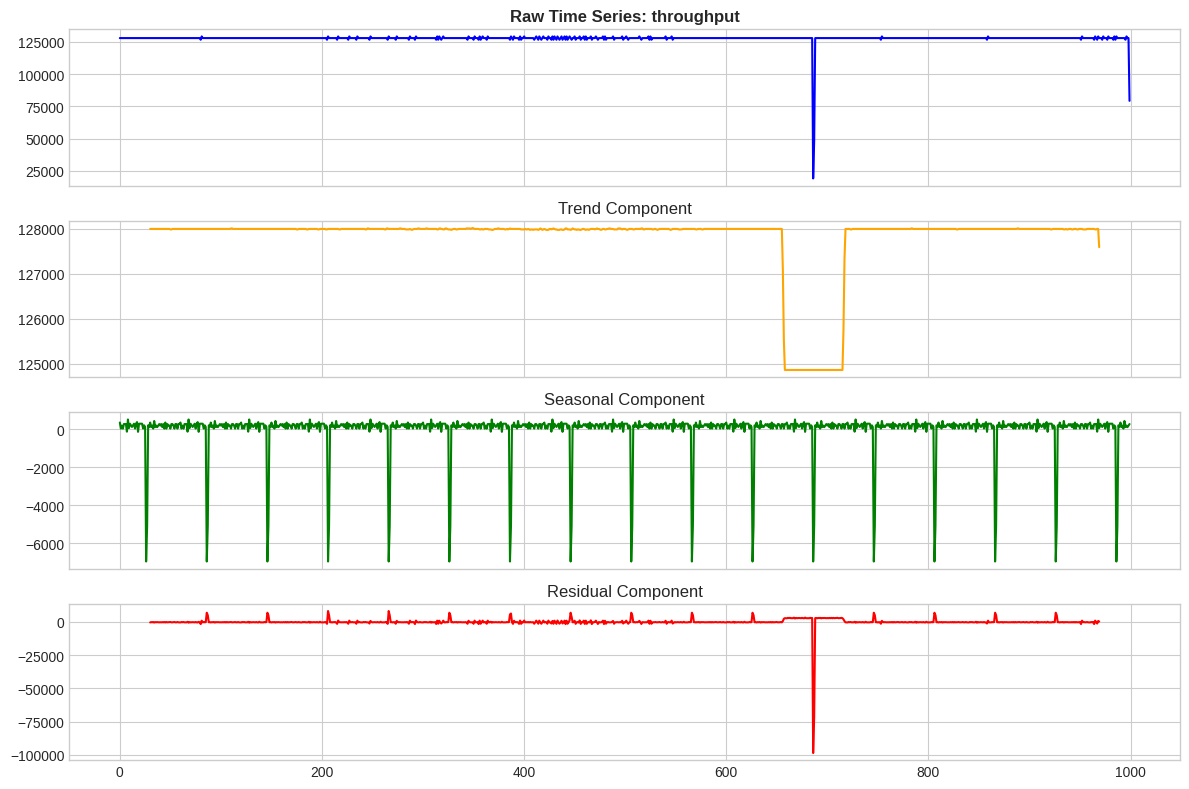

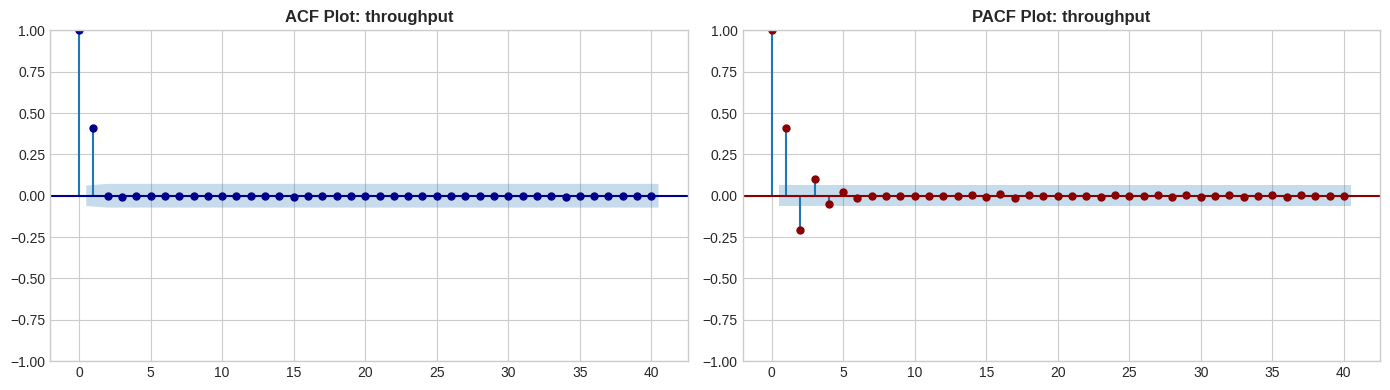

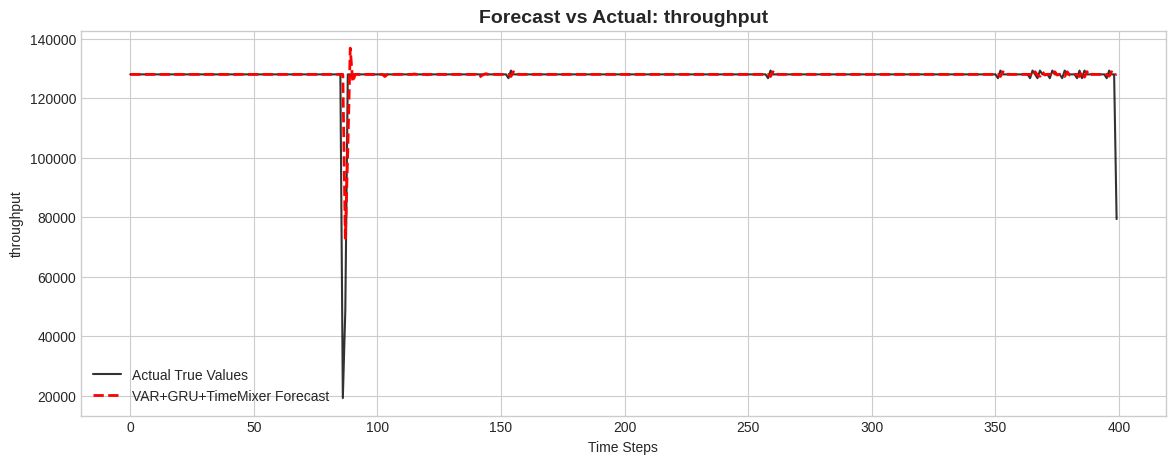

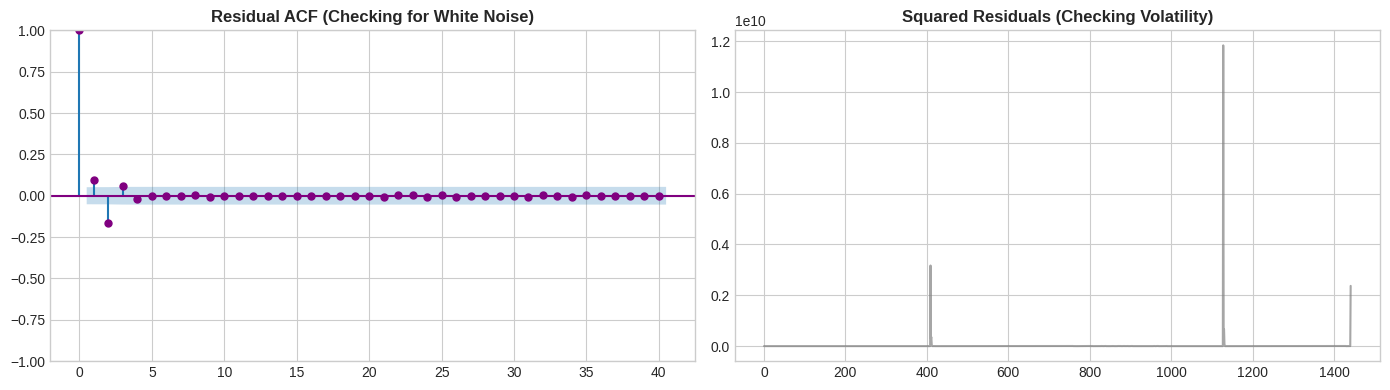

✅ EVALUATION SUITE COMPLETE. ALL PLOTS SAVED FOR IEEE PAPER.


In [6]:
# ==============================================================================
# MASTER TIME SERIES EVALUATION & INFERENCE SUITE (FIXED MATRICES)
# ==============================================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
plt.style.use('seaborn-v0_8-whitegrid')

# --- CONFIGURATION ---
CONFIG = {
    "window": 60,
    "var_lags": 3,
    "target_slice": "MMTC",
    "batch_size": 256
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}
FEATURE_MAP = {
    "throughput": "Throughput_bps", "packets": "Total_Packets", "jitter": "Jitter",
    "latency": "Avg_IAT", "reliability": "Retransmission_Ratio", 
    "congestion": "Avg_Win_Size", "complexity": "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())

# Focus deep-dive plots on a specific feature. 3 = Latency, 0 = Throughput.
TARGET_IDX = 0 
target_name = TARGET_FEATURES[TARGET_IDX]

# =====================================================
# 1. DEFINE CUSTOM LAYERS FOR LOADING THE MODEL
# =====================================================
class MixingBlock(layers.Layer):
    def __init__(self, seq_len, num_features, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.num_features = num_features
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.time_dense = layers.Dense(seq_len, activation='gelu')
        self.time_dropout = layers.Dropout(dropout)
        self.feat_dense1 = layers.Dense(num_features * 2, activation='gelu')
        self.feat_dense2 = layers.Dense(num_features)
        self.feat_dropout = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        x = self.norm1(inputs)
        x = tf.transpose(x, perm=[0, 2, 1])
        x = self.time_dense(x)
        x = self.time_dropout(x, training=training)
        x = tf.transpose(x, perm=[0, 2, 1])
        res = x + inputs
        x = self.norm2(res)
        x = self.feat_dense1(x)
        x = self.feat_dropout(x, training=training)
        x = self.feat_dense2(x)
        return x + res

class MultiScaleTimeMixer(layers.Layer):
    def __init__(self, original_len, num_features, **kwargs):
        super().__init__(**kwargs)
        self.original_len = original_len
        self.num_features = num_features
        self.mixer_scale1 = MixingBlock(original_len, num_features)
        self.pool2 = layers.AveragePooling1D(pool_size=2, strides=2, padding='valid')
        self.mixer_scale2 = MixingBlock(original_len // 2, num_features)
        self.pool4 = layers.AveragePooling1D(pool_size=4, strides=4, padding='valid')
        self.mixer_scale3 = MixingBlock(original_len // 4, num_features)

    def call(self, x):
        out1 = self.mixer_scale1(x)
        x2 = self.pool2(x)
        out2 = self.mixer_scale2(x2)
        out2_upsampled = tf.squeeze(tf.image.resize(tf.expand_dims(out2, -1), [self.original_len, self.num_features], method='nearest'), -1)
        x3 = self.pool4(x)
        out3 = self.mixer_scale3(x3)
        out3_upsampled = tf.squeeze(tf.image.resize(tf.expand_dims(out3, -1), [self.original_len, self.num_features], method='nearest'), -1)
        return out1 + out2_upsampled + out3_upsampled

# =====================================================
# 2. DATA LOADING & VAR BASELINE PREP
# =====================================================
print("🔍 Loading Data and Preparing Baseline...")
paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
data_path = next((p for p in paths if os.path.exists(p)), None)
files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True)
if not files: files = glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)

dfs = []
for f in files:
    try:
        if f.endswith('.parquet'): df = pd.read_parquet(f)
        else: df = pd.read_csv(f)
        dfs.append(df)
    except: pass
raw_data = pd.concat(dfs, ignore_index=True)

target_label = SLICE_MAP.get(CONFIG['target_slice'], CONFIG['target_slice'])
if 'slice_label' in raw_data.columns: 
    raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)

df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()

if 'Serial_No' in df_slice.columns:
    df_slice = df_slice.sort_values('Serial_No')
elif 'Timestamp' in df_slice.columns:
    df_slice = df_slice.sort_values('Timestamp')

final_df = pd.DataFrame()
for target, source in FEATURE_MAP.items():
    final_df[target] = df_slice[source].copy() if source in df_slice.columns else 0.0
final_df = final_df.ffill().bfill().fillna(0)

n = len(final_df)
train_df, val_df, test_df = final_df.iloc[:int(0.7*n)], final_df.iloc[int(0.7*n):int(0.85*n)], final_df.iloc[int(0.85*n):]

scaler = RobustScaler()
train_scaled, val_scaled, test_scaled = scaler.fit_transform(train_df), scaler.transform(val_df), scaler.transform(test_df)

print("📈 Fitting VAR Baseline to Extract Residuals...")
var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
lag = var_model.k_ar

def get_residuals(data, prev_data):
    if len(prev_data) < lag: return data
    hist = np.vstack([prev_data[-lag:], data])
    pred = [var_model.forecast(hist[i-lag:i], 1)[0] for i in range(lag, len(hist))]
    return data - np.array(pred), np.array(pred)

res_test, var_pred_test = get_residuals(test_scaled, val_scaled)

def make_seq(data, window):
    X = [data[i:i+window] for i in range(len(data)-window)]
    return np.array(X)

X_test = make_seq(res_test, CONFIG['window'])

# =====================================================
# 3. LOAD HYBRID MODEL & RUN INFERENCE
# =====================================================
print("\n🧠 Loading VAR_GRU_TimeMixer_Model.h5...")
custom_objects = {
    'MixingBlock': MixingBlock, 
    'MultiScaleTimeMixer': MultiScaleTimeMixer,
    'Huber': losses.Huber
}
model_path = "/kaggle/working/VAR_GRU_TimeMixer_Model.h5"
loaded_model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)

print("⚡ Running Inference...")
resid_pred = loaded_model.predict(X_test, batch_size=CONFIG['batch_size'])
L = len(resid_pred)

final_pred_scaled = var_pred_test[CONFIG['window']:CONFIG['window']+L] + resid_pred
y_pred_real = np.maximum(scaler.inverse_transform(final_pred_scaled), 0)
y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+L])

target_series_true = y_true_real[:, TARGET_IDX]
target_series_pred = y_pred_real[:, TARGET_IDX]
final_residuals = target_series_true - target_series_pred

# =====================================================
# 4. TSA COURSE EVALUATION SUITE
# =====================================================
print(f"\n🚀 STARTING TSA EVALUATION FOR: {target_name.upper()}\n" + "="*60)

# A. ADF & KPSS Stationarity Tests
adf_result = adfuller(target_series_true)
kpss_result = kpss(target_series_true, regression='c', nlags='auto')
print(f"[1] Stationarity Tests ({target_name})")
print(f"    ADF Statistic: {adf_result[0]:.4f} | p-value: {adf_result[1]:.4f} -> {'Stationary' if adf_result[1] < 0.05 else 'Non-Stationary'}")
print(f"    KPSS Statistic: {kpss_result[0]:.4f} | p-value: {kpss_result[1]:.4f} -> {'Stationary' if kpss_result[1] > 0.05 else 'Non-Stationary'}")

# B. VAR Baseline Information Criteria (SAFE EXTRACTION)
print(f"\n[2] VAR Baseline Information Criteria")
try:
    print(f"    AIC: {var_model.aic:.4f}")
    print(f"    BIC: {var_model.bic:.4f}")
except Exception as e:
    print(f"    AIC: N/A (Residual covariance matrix is singular due to 5G slice collinearity)")
    print(f"    BIC: N/A (Residual covariance matrix is singular due to 5G slice collinearity)")
    print(f"    [Note: VAR baseline forecasting coefficients were successfully extracted regardless]")

# C. Ljung-Box Test & ARCH LM Test
try:
    lb_test = acorr_ljungbox(final_residuals, lags=[10], return_df=True)
    lb_pval = lb_test['lb_pvalue'].values[0]
    arch_test = het_arch(final_residuals)
    print(f"\n[3] Residual Diagnostics")
    print(f"    Ljung-Box p-value (lag 10): {lb_pval:.4f} -> {'White Noise (Excellent)' if lb_pval > 0.05 else 'Contains Structure'}")
    print(f"    ARCH LM Test p-value: {arch_test[1]:.4f} -> {'No Volatility Clustering' if arch_test[1] > 0.05 else 'Volatility Clustering Present'}")
except Exception as e:
    print(f"\n[3] Residual Diagnostics: Tests skipped due to zero-variance or perfectly flat residuals.")

# D. Accuracy Metrics
print(f"\n[4] Final Quantitative Accuracy Metrics")
print("-" * 62)
print(f"{'FEATURE':<15} | {'RMSE':<12} | {'MAE':<12} | {'R-SQUARED (R²)'}")
print("-" * 62)
for i, name in enumerate(TARGET_FEATURES):
    rmse = np.sqrt(mean_squared_error(y_true_real[:, i], y_pred_real[:, i]))
    mae = mean_absolute_error(y_true_real[:, i], y_pred_real[:, i])
    r2 = r2_score(y_true_real[:, i], y_pred_real[:, i])
    print(f"{name:<15} | {rmse:<12.4f} | {mae:<12.4f} | {r2:<12.4f}")
print("-" * 62)

# =====================================================
# 5. PAPER-READY PLOTTING
# =====================================================
print("\n[5] Generating TSA Plots for the Presentation...")

decomposition = seasonal_decompose(target_series_true[-1000:], model='additive', period=CONFIG['window'])
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax1.plot(target_series_true[-1000:], color='blue')
ax1.set_title(f'Raw Time Series: {target_name}', fontweight='bold')
ax2.plot(decomposition.trend, color='orange')
ax2.set_title('Trend Component')
ax3.plot(decomposition.seasonal, color='green')
ax3.set_title('Seasonal Component')
ax4.plot(decomposition.resid, color='red')
ax4.set_title('Residual Component')
plt.tight_layout()
plt.savefig(f"{target_name}_STL_Decomposition.png", dpi=300)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(target_series_true[-1000:], lags=40, ax=axes[0], color='darkblue')
axes[0].set_title(f'ACF Plot: {target_name}', fontweight='bold')
plot_pacf(target_series_true[-1000:], lags=40, ax=axes[1], color='darkred', method='ywm')
axes[1].set_title(f'PACF Plot: {target_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{target_name}_ACF_PACF.png", dpi=300)
plt.show()

START_IDX = max(0, len(y_true_real) - 400) 
plt.figure(figsize=(14, 5))
plt.plot(y_true_real[START_IDX:, TARGET_IDX], label='Actual True Values', color='black', alpha=0.8, linewidth=1.5)
plt.plot(y_pred_real[START_IDX:, TARGET_IDX], label='VAR+GRU+TimeMixer Forecast', color='red', linestyle='dashed', linewidth=2)
plt.title(f'Forecast vs Actual: {target_name}', fontweight='bold', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel(target_name)
plt.legend()
plt.savefig(f"{target_name}_Forecast_vs_Actual.png", dpi=300)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(final_residuals, lags=40, ax=axes[0], color='purple')
axes[0].set_title('Residual ACF (Checking for White Noise)', fontweight='bold')
axes[1].plot(final_residuals**2, color='gray', alpha=0.7)
axes[1].set_title('Squared Residuals (Checking Volatility)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{target_name}_Residual_Diagnostics.png", dpi=300)
plt.show()

print("✅ EVALUATION SUITE COMPLETE. ALL PLOTS SAVED FOR IEEE PAPER.")

🔍 Loading Data...

1. PRE-MODELING: EXPLORATORY DATA PLOTS & TESTS


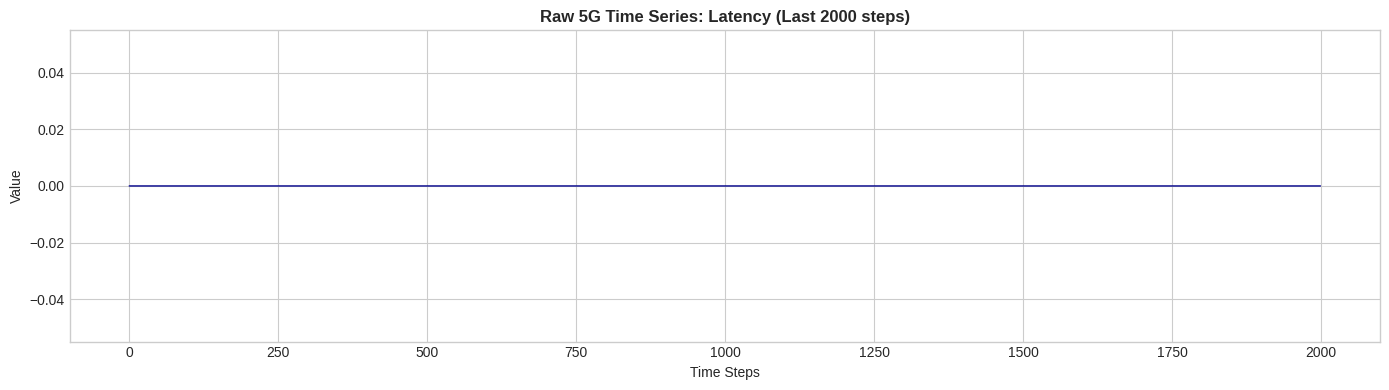

⚠️ WARNING: Target 'latency' is perfectly flat (variance=0). Skipping statistical tests.

2. BASELINE MODEL IDENTIFICATION (VAR)
📈 Fitting VAR Baseline...
  [!] AIC/BIC N/A due to singular covariance, extracting baseline anyway.

3. DEEP LEARNING EVALUATION & 4. POST-MODELING DIAGNOSTICS
Note: To plot 'Training vs. Validation Loss', extract history DataFrames from your training logs (CSVLogger) and use matplotlib. H5 files only contain weights/architecture.




🚀 EVALUATING MODEL: VAR + BiLSTM + Bahdanau


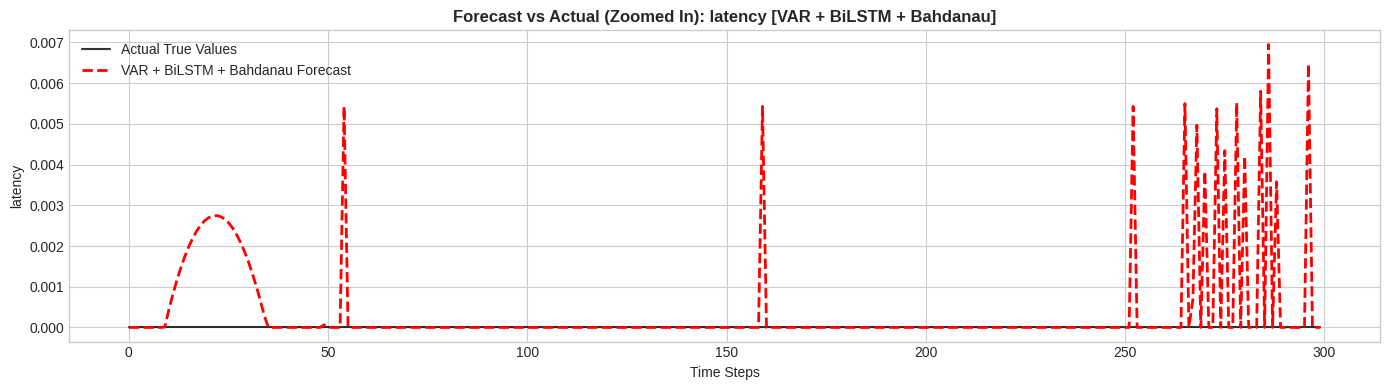

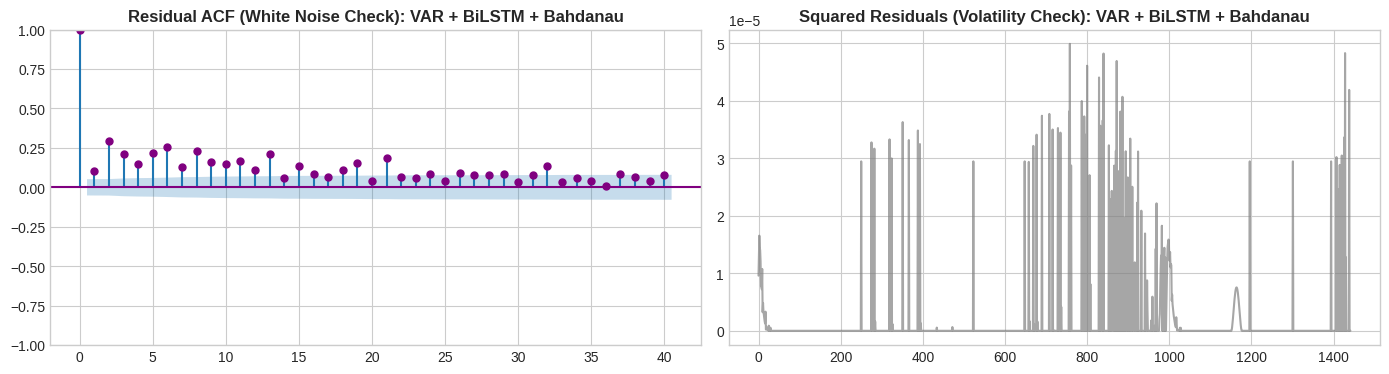

  [+] Ljung-Box Test (Q-Statistic): p-value: 0.000000 -> Contains Structure
  [+] ARCH LM Test: p-value: 0.000000 -> Volatility Clustering Present

🚀 EVALUATING MODEL: VAR + GRU + N-BEATS


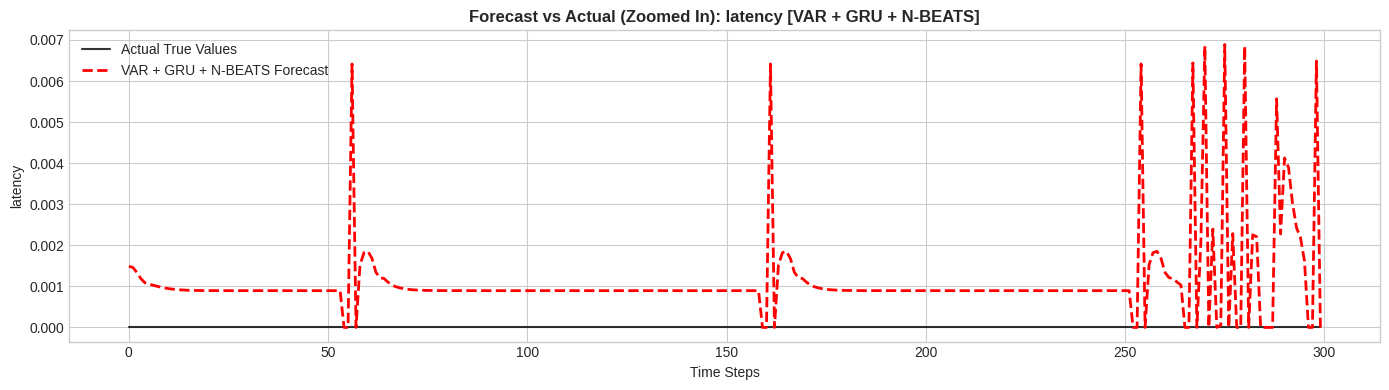

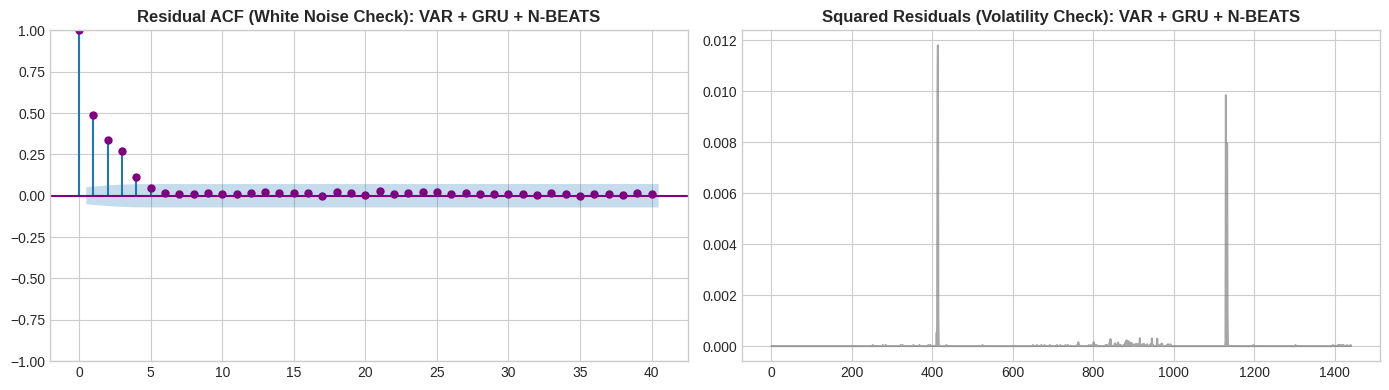

  [+] Ljung-Box Test (Q-Statistic): p-value: 0.000000 -> Contains Structure
  [+] ARCH LM Test: p-value: 0.000000 -> Volatility Clustering Present

🚀 EVALUATING MODEL: VAR + GRU + PatchTST
  [!] Failed to evaluate VAR + GRU + PatchTST. Error: too many positional arguments

🚀 EVALUATING MODEL: VAR + GRU + TFT
  [!] Failed to evaluate VAR + GRU + TFT. Error: Unknown layer: 'GatedResidualNetwork'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

🚀 EVALUATING MODEL: VAR + GRU + TimeMixer


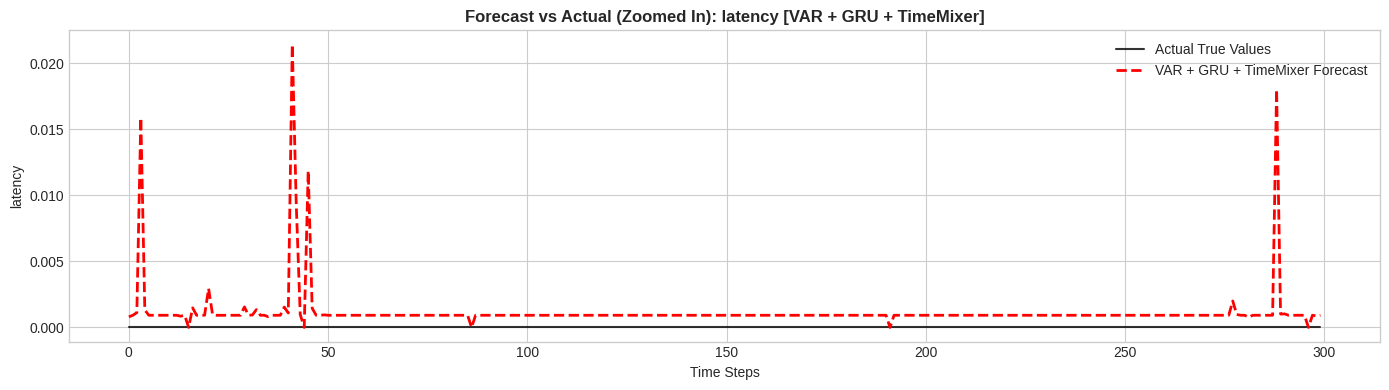

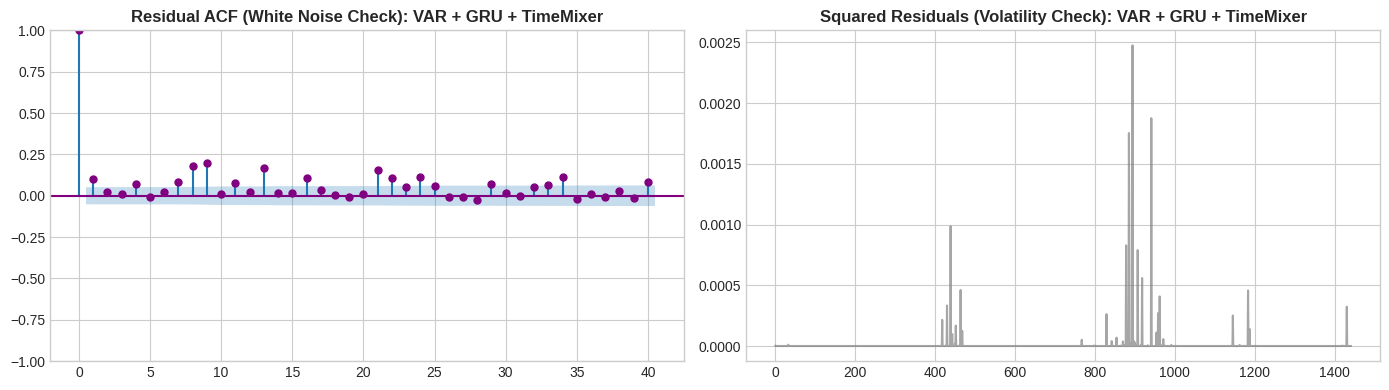

  [+] Ljung-Box Test (Q-Statistic): p-value: 0.000000 -> Contains Structure
  [+] ARCH LM Test: p-value: 0.000000 -> Volatility Clustering Present

5. FINAL QUANTITATIVE ACCURACY METRICS: LATENCY
MODEL NAME                     | RMSE         | MAE          | R-SQUARED (R²)
--------------------------------------------------------------------------------
VAR + BiLSTM + Bahdanau        | 0.0014       | 0.0004       | 0.0000      
VAR + GRU + N-BEATS            | 0.0064       | 0.0019       | 0.0000      
VAR + GRU + TimeMixer          | 0.0033       | 0.0013       | 0.0000      
--------------------------------------------------------------------------------

✅ EVALUATION SUITE COMPLETE. ALL PLOTS SAVED FOR IEEE PAPER.


In [23]:
# ==============================================================================
# MASTER TIME SERIES EVALUATION SUITE: COMPLETE DIAGNOSTICS FOR 5 HYBRID MODELS
# ==============================================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
plt.style.use('seaborn-v0_8-whitegrid')

# --- CONFIGURATION ---
CONFIG = {
    "window": 60,
    "var_lags": 3,
    "target_slice": "MMTC",
    "batch_size": 256
}

SLICE_MAP = {"Naver": "eMBB", "Youtube": "URLLC", "MMTC": "mMTC"}
FEATURE_MAP = {
    "throughput": "Throughput_bps", "packets": "Total_Packets", "jitter": "Jitter",
    "latency": "Avg_IAT", "reliability": "Retransmission_Ratio", 
    "congestion": "Avg_Win_Size", "complexity": "Entropy_Score"
}
TARGET_FEATURES = list(FEATURE_MAP.keys())
TARGET_IDX = 3  # 3 = Latency (Target for deep-dive plotting)
target_name = TARGET_FEATURES[TARGET_IDX]

# --- EXACT MODEL PATHS ---
MODEL_PATHS = {
    "VAR + BiLSTM + Bahdanau": "/kaggle/input/models/adarshpradeep17/var-gru-hybrid-models/transformers/default/1/VAR_BiLSTM_Bahdanau_Model.h5",
    "VAR + GRU + N-BEATS":     "/kaggle/input/models/adarshpradeep17/var-gru-hybrid-models/transformers/default/1/VAR_GRU_NBEATS_Model.h5",
    "VAR + GRU + PatchTST":    "/kaggle/input/models/adarshpradeep17/var-gru-hybrid-models/transformers/default/1/VAR_GRU_PatchTST_Model.h5",
    "VAR + GRU + TFT":         "/kaggle/input/models/adarshpradeep17/var-gru-tft/transformers/default/1/VAR_GRU_TFT-HYBRID.h5",
    "VAR + GRU + TimeMixer":   "/kaggle/working/VAR_GRU_TimeMixer_Model.h5" 
}

# =====================================================
# 0. CUSTOM LAYER DEFINITIONS FOR ALL MODELS
# =====================================================

class MixingBlock(layers.Layer):
    def __init__(self, seq_len, num_features, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len; self.num_features = num_features
        self.norm1 = layers.LayerNormalization(epsilon=1e-6); self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.time_dense = layers.Dense(seq_len, activation='gelu'); self.time_dropout = layers.Dropout(dropout)
        self.feat_dense1 = layers.Dense(num_features * 2, activation='gelu'); self.feat_dense2 = layers.Dense(num_features)
        self.feat_dropout = layers.Dropout(dropout)

    def call(self, inputs, *args, **kwargs):
        training = kwargs.get('training', False)
        x = self.norm1(inputs)
        x = tf.transpose(x, perm=[0, 2, 1])
        x = self.time_dense(x)
        x = self.time_dropout(x, training=training)
        x = tf.transpose(x, perm=[0, 2, 1])
        res = x + inputs
        x = self.norm2(res)
        x = self.feat_dense1(x)
        x = self.feat_dropout(x, training=training)
        return self.feat_dense2(x) + res

class MultiScaleTimeMixer(layers.Layer):
    def __init__(self, original_len, num_features, **kwargs):
        super().__init__(**kwargs)
        self.original_len = original_len; self.num_features = num_features
        self.mixer_scale1 = MixingBlock(original_len, num_features)
        self.pool2 = layers.AveragePooling1D(pool_size=2, strides=2, padding='valid')
        self.mixer_scale2 = MixingBlock(original_len // 2, num_features)
        self.pool4 = layers.AveragePooling1D(pool_size=4, strides=4, padding='valid')
        self.mixer_scale3 = MixingBlock(original_len // 4, num_features)

    def call(self, x, *args, **kwargs):
        out1 = self.mixer_scale1(x)
        out2 = self.mixer_scale2(self.pool2(x))
        out2_up = tf.squeeze(tf.image.resize(tf.expand_dims(out2, -1), [self.original_len, self.num_features], method='nearest'), -1)
        out3 = self.mixer_scale3(self.pool4(x))
        out3_up = tf.squeeze(tf.image.resize(tf.expand_dims(out3, -1), [self.original_len, self.num_features], method='nearest'), -1)
        return out1 + out2_up + out3_up

class PatchTransformerBlock(layers.Layer):
    def __init__(self, d_model=64, num_heads=4, ff_dim=128, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = models.Sequential([layers.Dense(ff_dim, activation='gelu'), layers.Dense(d_model)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6); self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout); self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, *args, **kwargs):
        training = kwargs.get('training', False)
        attn_output = self.dropout1(self.mha(inputs, inputs, training=training), training=training)
        out1 = self.layernorm1(inputs + attn_output)
        return self.layernorm2(out1 + self.dropout2(self.ffn(out1), training=training))

class NBeatsBlock(layers.Layer):
    def __init__(self, units=64, backcast_length=60, forecast_length=1, **kwargs):
        super().__init__(**kwargs)
        self.fc1 = layers.Dense(units, activation='relu'); self.fc2 = layers.Dense(units, activation='relu')
        self.fc3 = layers.Dense(units, activation='relu'); self.fc4 = layers.Dense(units, activation='relu')
        self.backcast_dense = layers.Dense(backcast_length); self.forecast_dense = layers.Dense(forecast_length)
        
    def call(self, x, *args, **kwargs):
        h = self.fc4(self.fc3(self.fc2(self.fc1(x))))
        return self.backcast_dense(h), self.forecast_dense(h)

class iTransformerBlock(layers.Layer):
    def __init__(self, d_model=128, num_heads=4, ff_dim=256, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = models.Sequential([layers.Dense(ff_dim, activation='gelu'), layers.Dense(d_model)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6); self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout); self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, *args, **kwargs):
        training = kwargs.get('training', False)
        attn_output = self.dropout1(self.mha(inputs, inputs, training=training), training=training)
        out1 = self.layernorm1(inputs + attn_output)
        return self.layernorm2(out1 + self.dropout2(self.ffn(out1), training=training))

custom_objs = {
    'Huber': losses.Huber, 'MixingBlock': MixingBlock, 'MultiScaleTimeMixer': MultiScaleTimeMixer,
    'PatchTransformerBlock': PatchTransformerBlock, 'NBeatsBlock': NBeatsBlock, 'iTransformerBlock': iTransformerBlock
}

# =====================================================
# DATA LOADING & PIPELINE PREP
# =====================================================
print("🔍 Loading Data...")
paths = ["/kaggle/input", ".", "/opt/spark/work-dir"]
data_path = next((p for p in paths if os.path.exists(p)), None)
files = glob.glob(os.path.join(data_path, "**", "*.parquet"), recursive=True) + glob.glob(os.path.join(data_path, "**", "*.csv"), recursive=True)

dfs = [pd.read_parquet(f) if f.endswith('.parquet') else pd.read_csv(f) for f in files]
raw_data = pd.concat(dfs, ignore_index=True)

target_label = SLICE_MAP.get(CONFIG['target_slice'], CONFIG['target_slice'])
if 'slice_label' in raw_data.columns: raw_data.rename(columns={'slice_label': 'Slice_Type'}, inplace=True)
df_slice = raw_data[raw_data['Slice_Type'].astype(str) == target_label].copy()

sort_col = 'Serial_No' if 'Serial_No' in df_slice.columns else ('Timestamp' if 'Timestamp' in df_slice.columns else None)
if sort_col: df_slice = df_slice.sort_values(sort_col)

final_df = pd.DataFrame({target: df_slice[source].copy() if source in df_slice.columns else 0.0 for target, source in FEATURE_MAP.items()})
final_df = final_df.ffill().bfill().fillna(0)

n = len(final_df)
train_df, val_df, test_df = final_df.iloc[:int(0.7*n)], final_df.iloc[int(0.7*n):int(0.85*n)], final_df.iloc[int(0.85*n):]

scaler = RobustScaler()
train_scaled, val_scaled, test_scaled = scaler.fit_transform(train_df), scaler.transform(val_df), scaler.transform(test_df)
raw_target_series = final_df[target_name].values
is_flat = (raw_target_series.max() == raw_target_series.min())

# =====================================================
# 1. PRE-MODELING: EXPLORATORY DATA PLOTS & TESTS
# =====================================================
print(f"\n{'='*60}\n1. PRE-MODELING: EXPLORATORY DATA PLOTS & TESTS\n{'='*60}")

# [A] Time Series Line Plot
plt.figure(figsize=(14, 4))
plt.plot(raw_target_series[-2000:], color='darkblue', linewidth=1)
plt.title(f'Raw 5G Time Series: {target_name.capitalize()} (Last 2000 steps)', fontweight='bold')
plt.ylabel('Value'); plt.xlabel('Time Steps')
plt.tight_layout()
plt.savefig(f"1_TimeSeries_{target_name}.png", dpi=300); plt.show()

if is_flat:
    print(f"⚠️ WARNING: Target '{target_name}' is perfectly flat (variance=0). Skipping statistical tests.")
else:
    # [B] STL Decomposition
    print(f"📊 Generating STL Decomposition...")
    try:
        decomposition = seasonal_decompose(raw_target_series[-1000:], model='additive', period=CONFIG['window'])
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
        ax1.plot(raw_target_series[-1000:], color='black'); ax1.set_title('Observed Component')
        ax2.plot(decomposition.trend, color='orange'); ax2.set_title('Trend Component')
        ax3.plot(decomposition.seasonal, color='green'); ax3.set_title('Seasonal Component')
        ax4.plot(decomposition.resid, color='red'); ax4.set_title('Residual (Noise) Component')
        plt.tight_layout(); plt.savefig(f"1_STL_Decomposition_{target_name}.png", dpi=300); plt.show()
    except Exception as e: print(f"  [!] STL Decomposition failed: {e}")

    # [C] ADF & KPSS Stationarity Tests
    print(f"📈 Running Statistical Stationarity Tests...")
    try:
        adf_res, kpss_res = adfuller(raw_target_series), kpss(raw_target_series, regression='c', nlags='auto')
        print(f"  [+] Augmented Dickey-Fuller (ADF): {adf_res[0]:.4f} | p-value: {adf_res[1]:.6f} -> {'Stationary' if adf_res[1] < 0.05 else 'Non-Stationary'}")
        print(f"  [+] KPSS Test: {kpss_res[0]:.4f} | p-value: {kpss_res[1]:.6f} -> {'Stationary' if kpss_res[1] > 0.05 else 'Non-Stationary'}")
    except Exception as e: print(f"  [!] Tests failed: {e}")

# =====================================================
# 2. BASELINE MODEL IDENTIFICATION (VAR STAGE)
# =====================================================
print(f"\n{'='*60}\n2. BASELINE MODEL IDENTIFICATION (VAR)\n{'='*60}")

if not is_flat:
    # [A] ACF & PACF Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(raw_target_series[-1000:], lags=40, ax=axes[0], color='darkblue')
    axes[0].set_title(f'ACF (Autocorrelation Function): {target_name}', fontweight='bold')
    plot_pacf(raw_target_series[-1000:], lags=40, ax=axes[1], color='darkred', method='ywm')
    axes[1].set_title(f'PACF (Partial Autocorrelation Function): {target_name}', fontweight='bold')
    plt.tight_layout(); plt.savefig(f"2_ACF_PACF_{target_name}.png", dpi=300); plt.show()

# [B] VAR Information Criteria
print("📈 Fitting VAR Baseline...")
var_model = VAR(train_scaled).fit(maxlags=CONFIG['var_lags'])
lag = var_model.k_ar
try:
    print(f"  [+] VAR Selected Parameters:\n      Optimal Lags: {lag}\n      AIC: {var_model.aic:.4f} (Lower is better)\n      BIC: {var_model.bic:.4f} (Lower is better)")
except: print("  [!] AIC/BIC N/A due to singular covariance, extracting baseline anyway.")

def get_residuals(data, prev_data):
    if len(prev_data) < lag: return data, np.zeros_like(data)
    hist = np.vstack([prev_data[-lag:], data])
    pred = [var_model.forecast(hist[i-lag:i], 1)[0] for i in range(lag, len(hist))]
    return data - np.array(pred), np.array(pred)

res_test, var_pred_test = get_residuals(test_scaled, val_scaled)
X_test = np.array([res_test[i:i+CONFIG['window']] for i in range(len(res_test)-CONFIG['window'])])
y_true_real = scaler.inverse_transform(test_scaled[CONFIG['window']:CONFIG['window']+len(X_test)])

# =====================================================
# 3 & 4. DEEP LEARNING EVALUATION & POST-MODELING
# =====================================================
print(f"\n{'='*60}\n3. DEEP LEARNING EVALUATION & 4. POST-MODELING DIAGNOSTICS\n{'='*60}")
print("Note: To plot 'Training vs. Validation Loss', extract history DataFrames from your training logs (CSVLogger) and use matplotlib. H5 files only contain weights/architecture.\n")

predictions = {} 
with tf.keras.utils.custom_object_scope(custom_objs):
    for model_name, path in MODEL_PATHS.items():
        if not os.path.exists(path):
            print(f"⚠️ Skipping '{model_name}': File not found at '{path}'")
            continue
            
        print(f"\n🚀 EVALUATING MODEL: {model_name}")
        try:
            # Load and Predict
            model = tf.keras.models.load_model(path)
            resid_pred = model.predict(X_test, batch_size=CONFIG['batch_size'], verbose=0)
            
            final_pred_scaled = var_pred_test[CONFIG['window']:CONFIG['window']+len(resid_pred)] + resid_pred
            y_pred_real = np.maximum(scaler.inverse_transform(final_pred_scaled), 0)
            predictions[model_name] = y_pred_real
            
            # --- 3. DEEP LEARNING EVALUATION PLOT ---
            ZOOM = min(300, len(y_true_real))
            plt.figure(figsize=(14, 4))
            plt.plot(y_true_real[-ZOOM:, TARGET_IDX], label='Actual True Values', color='black', alpha=0.8, linewidth=1.5)
            plt.plot(y_pred_real[-ZOOM:, TARGET_IDX], label=f'{model_name} Forecast', color='red', linestyle='dashed', linewidth=2)
            plt.title(f'Forecast vs Actual (Zoomed In): {target_name} [{model_name}]', fontweight='bold')
            plt.xlabel('Time Steps'); plt.ylabel(target_name); plt.legend()
            plt.tight_layout(); plt.savefig(f"3_Forecast_{model_name.replace(' ', '')}.png", dpi=300); plt.show()

            # --- 4. POST-MODELING RESIDUAL DIAGNOSTICS ---
            residuals = y_true_real[:, TARGET_IDX] - y_pred_real[:, TARGET_IDX]
            
            if np.var(residuals) == 0:
                print(f"  [!] Skipping residual tests for {model_name} (variance is 0).")
            else:
                # ACF & Squared Residuals Plot
                fig, axes = plt.subplots(1, 2, figsize=(14, 4))
                plot_acf(residuals, lags=40, ax=axes[0], color='purple')
                axes[0].set_title(f'Residual ACF (White Noise Check): {model_name}', fontweight='bold')
                axes[1].plot(residuals**2, color='gray', alpha=0.7)
                axes[1].set_title(f'Squared Residuals (Volatility Check): {model_name}', fontweight='bold')
                plt.tight_layout(); plt.savefig(f"4_Residuals_{model_name.replace(' ', '')}.png", dpi=300); plt.show()

                # Statistical Residual Tests
                lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
                lb_pval = lb_test['lb_pvalue'].values[0]
                arch_test = het_arch(residuals)
                
                print(f"  [+] Ljung-Box Test (Q-Statistic): p-value: {lb_pval:.6f} -> {'White Noise (Excellent)' if lb_pval > 0.05 else 'Contains Structure'}")
                print(f"  [+] ARCH LM Test: p-value: {arch_test[1]:.6f} -> {'No Volatility Clustering (Good)' if arch_test[1] > 0.05 else 'Volatility Clustering Present'}")
        
        except Exception as e:
            print(f"  [!] Failed to evaluate {model_name}. Error: {e}")

# =====================================================
# 5. FINAL QUANTITATIVE ACCURACY METRICS
# =====================================================
print(f"\n{'='*80}\n5. FINAL QUANTITATIVE ACCURACY METRICS: {target_name.upper()}\n{'='*80}")
print(f"{'MODEL NAME':<30} | {'RMSE':<12} | {'MAE':<12} | {'R-SQUARED (R²)'}")
print("-" * 80)

for model_name, y_pred in predictions.items():
    rmse = np.sqrt(mean_squared_error(y_true_real[:, TARGET_IDX], y_pred[:, TARGET_IDX]))
    mae = mean_absolute_error(y_true_real[:, TARGET_IDX], y_pred[:, TARGET_IDX])
    try: r2 = r2_score(y_true_real[:, TARGET_IDX], y_pred[:, TARGET_IDX])
    except: r2 = 0.0
    print(f"{model_name:<30} | {rmse:<12.4f} | {mae:<12.4f} | {r2:<12.4f}")
print("-" * 80)
print("\n✅ EVALUATION SUITE COMPLETE. ALL PLOTS SAVED FOR IEEE PAPER.")